#### **프로젝트 개요**
## 부산 15분 아동돌봄 생활권 구축: 들락날락 중심 허브-위성형 방과후 돌봄 연계 모델

#### 돌봄 수요 및 공급 지도를 만들고, E2SFCA 기반 접근성을 분석합니다.
* 수요자: 초등학생 인구, 만 7~12세

  (중학생은 스스로 보호 능력이 있고, 영유아는 시설까지 스스로 접근하기 어려워 제외)
* 임계거리: 750m (이 거리 안에 있으면 이용 가능하다고 보는 기준)
* 거리 계산: 도로망 네트워크 거리 기준
* E2SFCA 계산
  - 1단계: 시설별 수요 대비 공급비 계산. `시설 j의 공급비 = 1 / 750m 안의 가중 아동 인구`
  - 2단계: 격자별 접근성 계산. `격자 i의 접근성 = 주변 시설들의 공급비 합`
  - 거리 가중치는 가우시안 함수 사용(거리가 멀어질수록 가중치 낮춤)
* 최종 행정동 접근성 = 해당 행정동 안에 포함된 100m 격자 접근성의 산술평균



In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 폰트 설정 사용하는 환경에 따라 수정하시면 됩니다.
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 초등학생 인구 100m 격자 지도

In [2]:
# 인구 100m 격자 데이터 불러오기

gdf = gpd.read_file("busan_100m_population_5179.gpkg")

# 인구값 컬럼
pop_col = "val"

# 인구값 숫자형 변환
gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce")

# 좌표계 확인
print("좌표계:", gdf.crs)
print("컬럼 목록:", gdf.columns.tolist())
print(gdf[[pop_col]].describe())

좌표계: EPSG:5179
컬럼 목록: ['gid', 'val', 'pop_class', 'geometry']
                val
count  10825.000000
mean      13.008776
std       23.154212
min        0.000000
25%        0.000000
50%        6.000000
75%       17.000000
max      483.000000


In [3]:
# =========================
# 3. QGIS SLD 스타일 정보
# =========================

bins = [-np.inf, 7, 11, 16, 22, 27, 37, np.inf]

labels = [
    "7 이하",
    "7 - 11 이하",
    "11 - 16 이하",
    "16 - 22 이하",
    "22 - 27 이하",
    "27 - 37 이하",
    "37 이상"
]

colors = {
    "7 이하": "#FFF5EB",
    "7 - 11 이하": "#FEE6CE",
    "11 - 16 이하": "#FDD0A2",
    "16 - 22 이하": "#FDAE6B",
    "22 - 27 이하": "#FD8D3C",
    "27 - 37 이하": "#F16913",
    "37 이상": "#CC4704"
}

# 인구 구간 생성
gdf["pop_class"] = pd.cut(
    gdf[pop_col],
    bins=bins,
    labels=labels,
    right=True
)

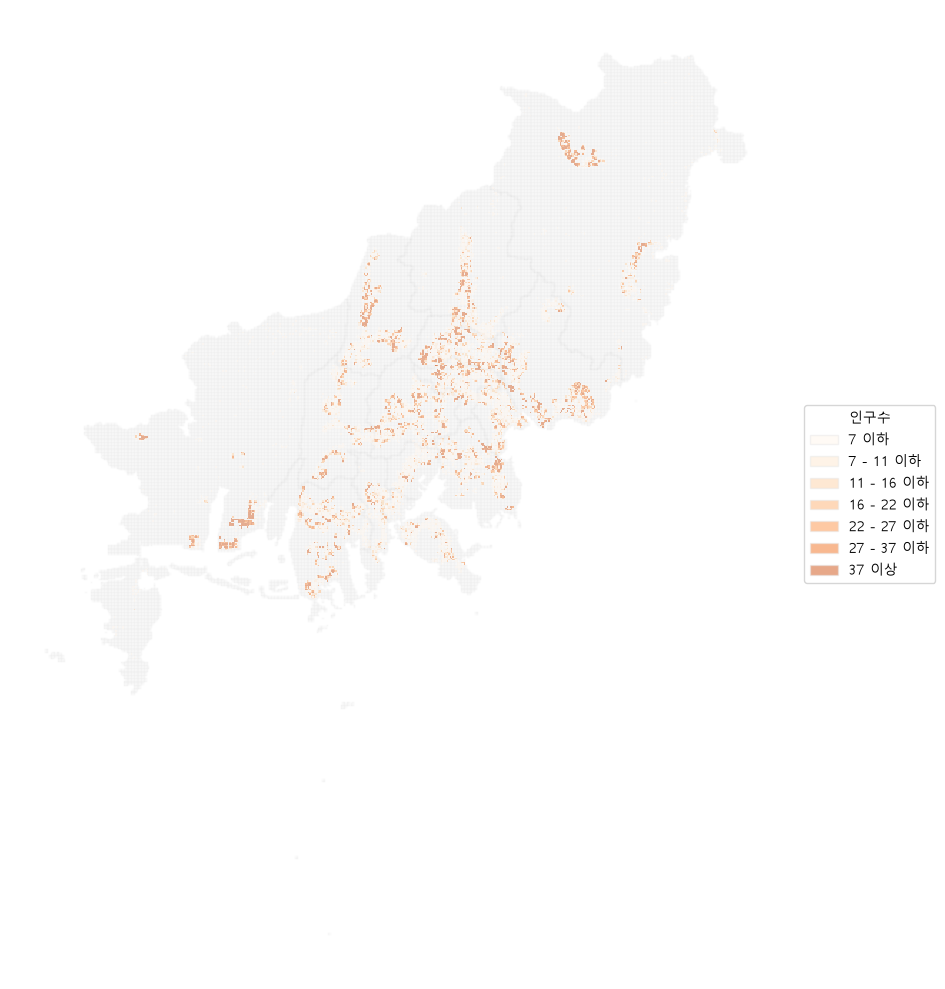

In [4]:

fig, ax = plt.subplots(figsize=(10, 10))

# 결측값 / 통계 없음
gdf[gdf["pop_class"].isna()].plot(
    ax=ax,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1
)

# 인구 구간별 색상 적용
for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.47
        )

# 범례 생성
legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.47,
        label=label
    )
    for label in labels
]

ax.legend(
    handles=legend_handles,
    title="인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_axis_off()
plt.tight_layout()
#fig.savefig("초등학생인구지도.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# 초등학생 인구 100m 격자 지도 + 다함께돌봄센터

전체 센터 수: 76
점 찍을 센터 수: 76
gdf 좌표계: EPSG:5179
center_gdf 좌표계: EPSG:5179
center_gdf 범위: [1121963.82514546 1675298.66141663 1156825.58408406 1704621.14233626]


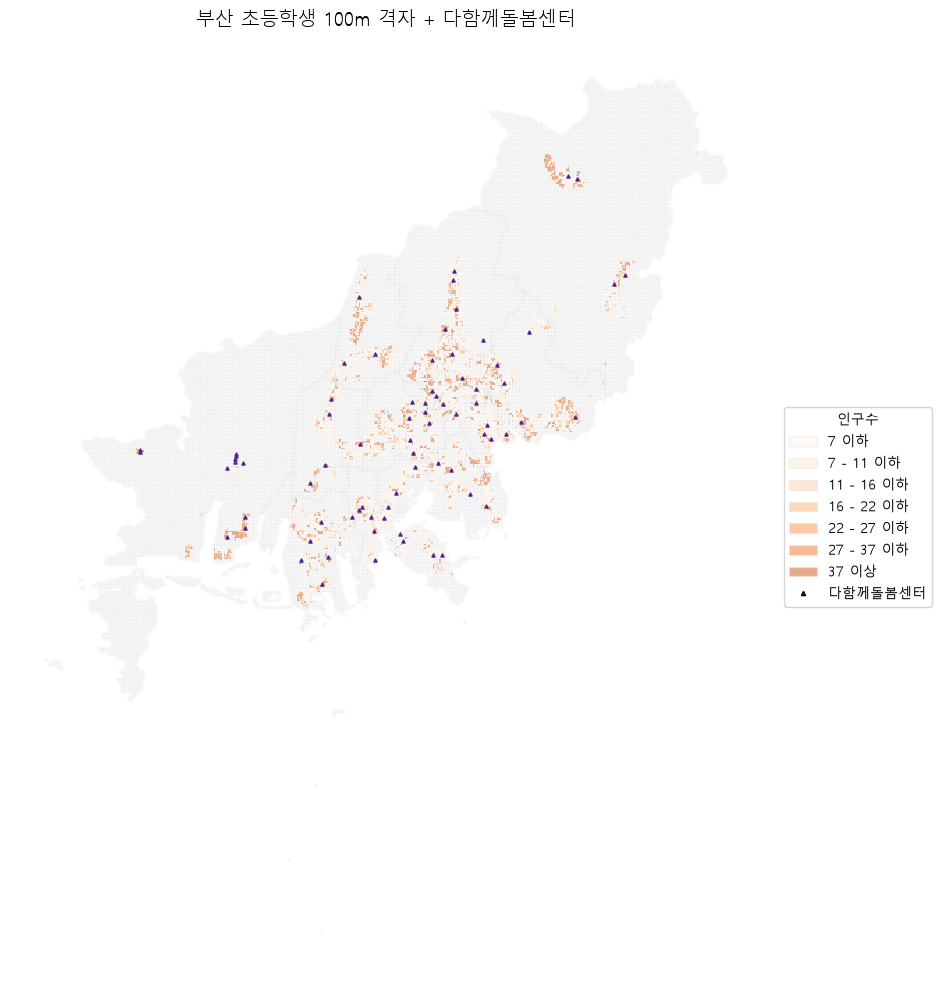

In [5]:
# =========================
# 인구 격자 + 다함께돌봄센터
# =========================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

center_df = pd.read_csv("다함께돌봄센터_현황.csv", encoding="utf-8-sig")

# lon, lat 숫자형으로 변환
center_df["lon"] = pd.to_numeric(center_df["lon"], errors="coerce")
center_df["lat"] = pd.to_numeric(center_df["lat"], errors="coerce")

# 좌표 있는 것만 사용
center_ok = center_df.dropna(subset=["lon", "lat"]).copy()

print("전체 센터 수:", len(center_df))
print("점 찍을 센터 수:", len(center_ok))

# 점 데이터 GeoDataFrame 만들기
center_gdf = gpd.GeoDataFrame(
    center_ok,
    geometry=gpd.points_from_xy(center_ok["lon"], center_ok["lat"]),
    crs="EPSG:4326"
)

# 격자 지도 gdf와 좌표계 맞추기
center_gdf = center_gdf.to_crs(gdf.crs)

print("gdf 좌표계:", gdf.crs)
print("center_gdf 좌표계:", center_gdf.crs)
print("center_gdf 범위:", center_gdf.total_bounds)

# 지도 만들자
fig2, ax2 = plt.subplots(figsize=(10, 10))

# 결측값 / 통계 없음
gdf[gdf["pop_class"].isna()].plot(
    ax=ax2,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1
)

# 인구 구간별 색상 적용
for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax2,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.47
        )

# 새 지도2 위에 돌봄센터 점 찍기
center_gdf.plot(
    ax=ax2,
    color="#54278F",
    markersize=5,
    marker="^",
    zorder=10
)

# 범례 만들기
legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.47,
        label=label
    )
    for label in labels
]

center_handle = plt.Line2D(
    [],
    [],
    marker="^",
    color="black",
    markerfacecolor="#54278F",
    markersize=3,
    linestyle="None",
    label="다함께돌봄센터"
)

legend_handles.append(center_handle)

ax2.legend(
    handles=legend_handles,
    title="인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax2.set_title("부산 초등학생 100m 격자 + 다함께돌봄센터", fontsize=14)
ax2.set_axis_off()

plt.tight_layout()
#fig2.savefig("초등학생인구_다함께돌봄센터.png", dpi=300, bbox_inches="tight", facecolor="white") #이미지 저장용
plt.show()

# 초등학생 인구 100m 격자 지도 + 들락날락

전체 들락날락 수: 102
점 찍을 수: 102
gdf 좌표계: EPSG:5179
dlnl_gdf 좌표계: EPSG:5179
gdf 범위: [1115100. 1650000. 1164200. 1711700.]
dlnl_gdf 범위: [1125115.99190242 1673803.6601909  1158078.87886551 1708557.32608938]


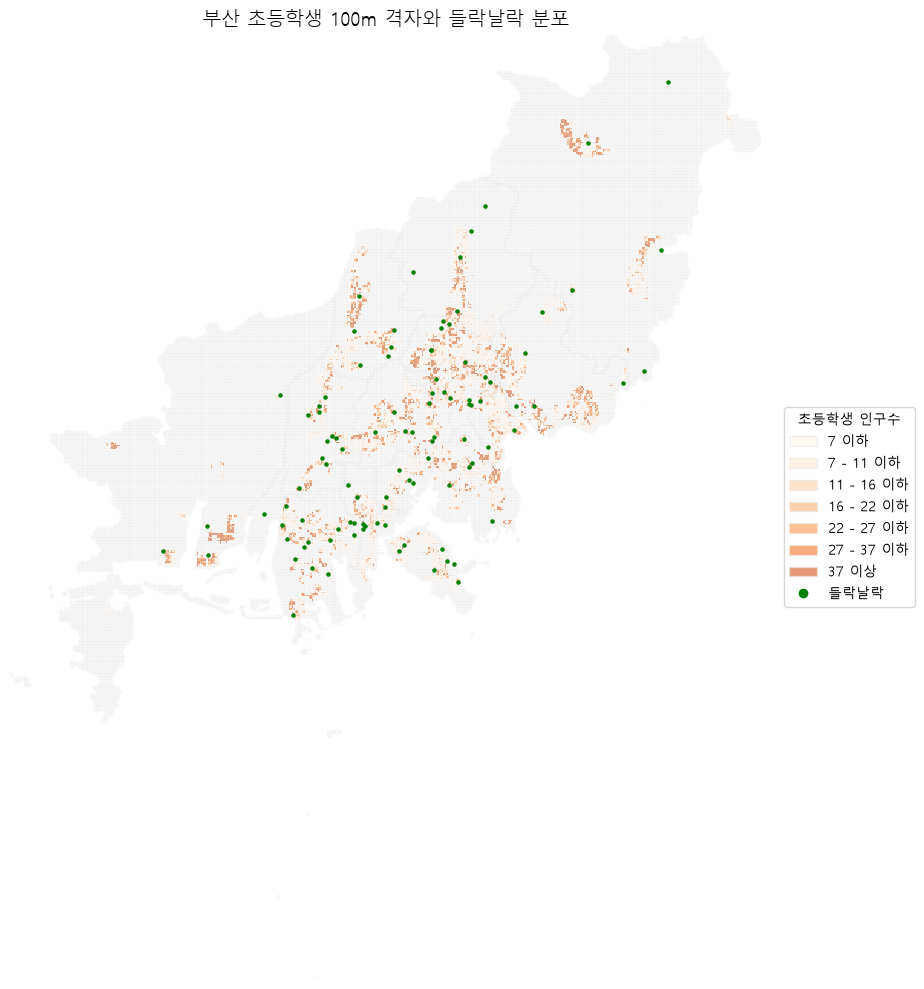

In [6]:
# =========================
# 초등학생 100m 인구 격자지도 + 들락날락
# =========================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

dlnl_df = pd.read_csv("busan_dlnl_homepage_102_coord.csv", encoding="utf-8-sig")


dlnl_df["위도"] = pd.to_numeric(dlnl_df["위도"], errors="coerce")
dlnl_df["경도"] = pd.to_numeric(dlnl_df["경도"], errors="coerce")


dlnl_ok = dlnl_df.dropna(subset=["위도", "경도"]).copy()

print("전체 들락날락 수:", len(dlnl_df))
print("점 찍을 수:", len(dlnl_ok))


dlnl_gdf = gpd.GeoDataFrame(
    dlnl_ok,
    geometry=gpd.points_from_xy(dlnl_ok["경도"], dlnl_ok["위도"]),
    crs="EPSG:4326"
)


dlnl_gdf = dlnl_gdf.to_crs(gdf.crs)

print("gdf 좌표계:", gdf.crs)
print("dlnl_gdf 좌표계:", dlnl_gdf.crs)
print("gdf 범위:", gdf.total_bounds)
print("dlnl_gdf 범위:", dlnl_gdf.total_bounds)

fig3, ax3 = plt.subplots(figsize=(10, 10))


gdf[gdf["pop_class"].isna()].plot(
    ax=ax3,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1,
    zorder=1
)

for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax3,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.55,
            zorder=2
        )

dlnl_gdf.plot(
    ax=ax3,
    color="green",
    markersize=5,
    marker="o",
    zorder=10,
    label="들락날락"
)


minx, miny, maxx, maxy = gdf.total_bounds
ax3.set_xlim(minx, maxx)
ax3.set_ylim(miny, maxy)

legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.55,
        label=label
    )
    for label in labels
]

dlnl_handle = plt.Line2D(
    [],
    [],
    marker="o",
    color="white",
    markerfacecolor="green",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="들락날락"
)

legend_handles.append(dlnl_handle)

ax3.legend(
    handles=legend_handles,
    title="초등학생 인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax3.set_title("부산 초등학생 100m 격자와 들락날락 분포", fontsize=14)
ax3.set_axis_off()

plt.tight_layout()
#fig3.savefig("초등학생인구_들락날락.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# 초등학생 인구 100m 격자 지도 + 들락날락 + 다함께 돌봄센터

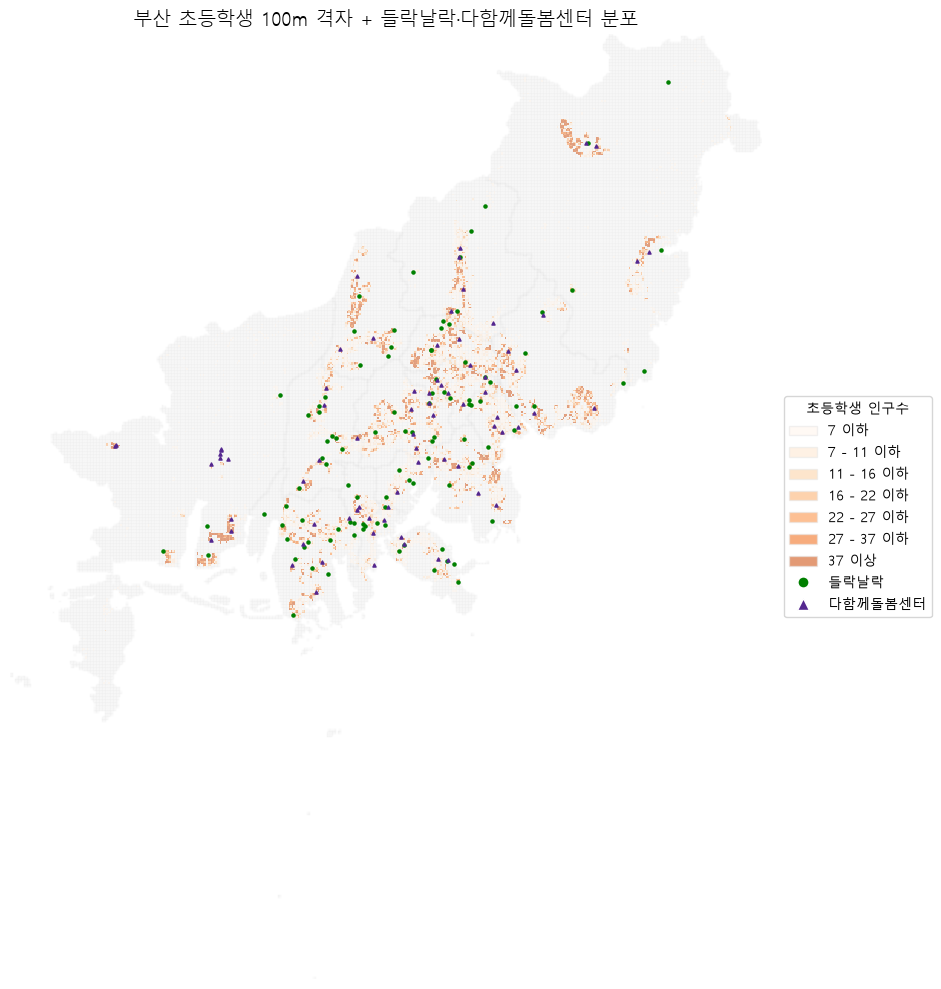

In [7]:
# =========================
# 초등학생 100m 인구 격자지도 + 들락날락 + 다함께돌봄센터
# =========================

fig4, ax4 = plt.subplots(figsize=(10, 10))

gdf[gdf["pop_class"].isna()].plot(
    ax=ax4,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1,
    zorder=1
)

for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax4,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.55,
            zorder=2
        )

dlnl_gdf.plot(
    ax=ax4,
    color="green",
    markersize=5,
    marker="o",
    zorder=10,
    label="들락날락"
)

center_gdf.plot(
    ax=ax4,
    color="#54278F",
    markersize=5,
    marker="^",
    zorder=11,
    label="다함께돌봄센터"
)

minx, miny, maxx, maxy = gdf.total_bounds
ax4.set_xlim(minx, maxx)
ax4.set_ylim(miny, maxy)

legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.55,
        label=label
    )
    for label in labels
]

dlnl_handle = plt.Line2D(
    [],
    [],
    marker="o",
    color="white",
    markerfacecolor="green",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="들락날락"
)

center_handle = plt.Line2D(
    [],
    [],
    marker="^",
    color="white",
    markerfacecolor="#54278F",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="다함께돌봄센터"
)

legend_handles.append(dlnl_handle)
legend_handles.append(center_handle)

ax4.legend(
    handles=legend_handles,
    title="초등학생 인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax4.set_title("부산 초등학생 100m 격자 + 들락날락·다함께돌봄센터 분포", fontsize=14)
ax4.set_axis_off()

plt.tight_layout()
#fig4.savefig("초등학생인구_들락날락_다함께돌봄센터.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# 초등학생 인구 100m 격자 지도 + 다함께돌봄센터 + 들락날락 + 지역아동센터

Index(['연번', '구군명', '법정동', '행정동', '기관명', '주소', '연락처', '운영요일', '휴무일', '(학기)시작',
       '(학기)종료', '(방학)시작', '(방학)종료', '이용대상', '이용요금', 'full_addr', 'lon', 'lat',
       'match_type', 'matched_query'],
      dtype='str')
   연번 구군명     법정동    행정동         기관명                           주소  \
0   1  중구   보수동1가    보수동  동광해들지역아동센터             중구 중구로 63(보수동1가)   
1   2  중구   보수동3가    보수동    희망지역아동센터         중구 흑교로45번길 13(보수동3가)   
2   3  중구     영주동   영주1동    지수지역아동센터          중구 대영로 242번길 4(영주동)   
3   4  서구    남부민동  남부민2동    해강지역아동센터         서구 해돋이로 71, 4층(남부민동)   
4   5  서구  동대신동3가  동대신3동    대신지역아동센터  서구 구덕로 346번길 17, 3층(동대신동3가)   

             연락처 운영요일        휴무일 (학기)시작 (학기)종료 (방학)시작 (방학)종료  \
0   051-246-7755  월-금  토, 일, 공휴일  10:00  19:00  10:00  19:00   
1   051-243-0912  월-금  토, 일, 공휴일  11:00  20:00  11:00  20:00   
2  070-8141-1001  월-금  토, 일, 공휴일  10:30  19:30  10:30  19:30   
3   051-241-1161  월-금  토, 일, 공휴일  11:00  20:00  11:00  20:00   
4   051-241-5681  월-금  토, 일, 공휴일  10:00  20:00  

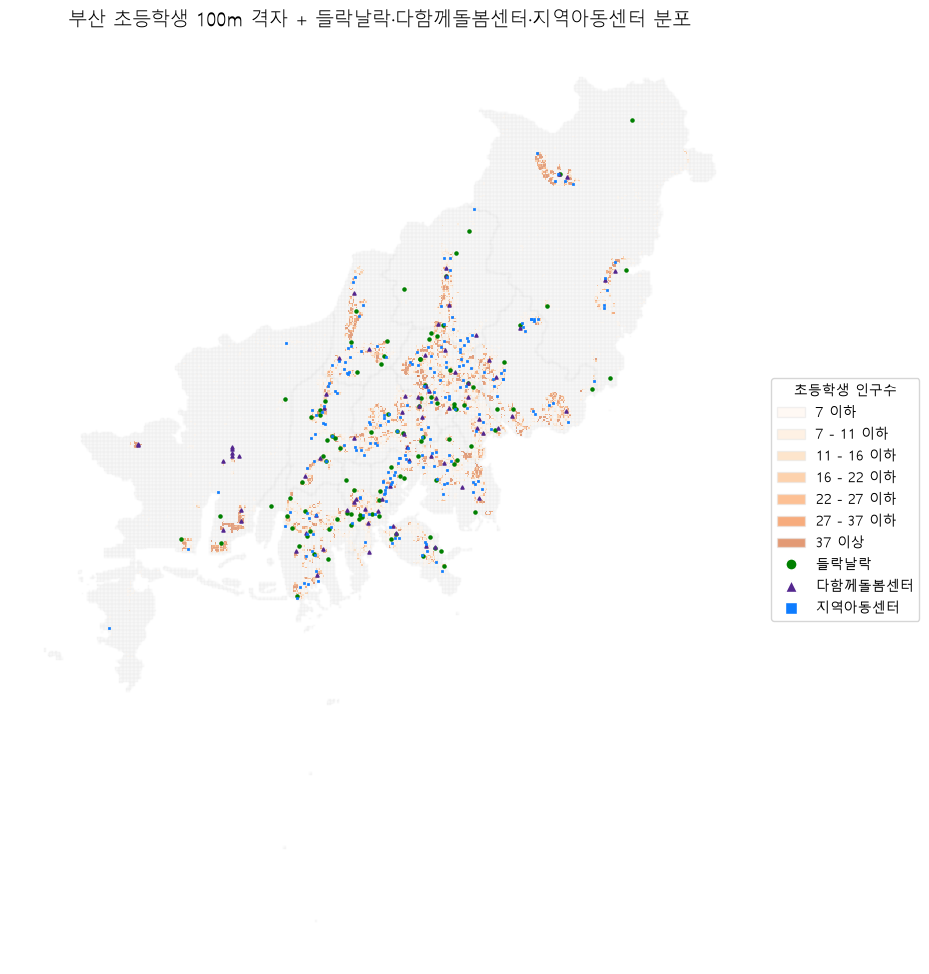

In [8]:
# =========================
# + 지역아동센터
# =========================

local_df = pd.read_csv("지역아동센터_시설현황.csv", encoding="utf-8-sig")

print(local_df.columns)
print(local_df.head())

local_df["lon"] = pd.to_numeric(local_df["lon"], errors="coerce")
local_df["lat"] = pd.to_numeric(local_df["lat"], errors="coerce")

local_ok = local_df.dropna(subset=["lon", "lat"]).copy()

print("지역아동센터 전체 수:", len(local_df))
print("점 찍을 수:", len(local_ok))

local_gdf = gpd.GeoDataFrame(
    local_ok,
    geometry=gpd.points_from_xy(local_ok["lon"], local_ok["lat"]),
    crs="EPSG:4326"
)

local_gdf = local_gdf.to_crs(gdf.crs)

print("local_gdf 범위:", local_gdf.total_bounds)

fig5, ax5 = plt.subplots(figsize=(10, 10))

gdf[gdf["pop_class"].isna()].plot(
    ax=ax5,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1,
    zorder=1
)

for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax5,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.55,
            zorder=2
        )

dlnl_gdf.plot(
    ax=ax5,
    color="green",
    markersize=5,
    marker="o",
    zorder=10,
    label="들락날락"
)

center_gdf.plot(
    ax=ax5,
    color="#54278F",
    markersize=5,
    marker="^",
    zorder=11,
    label="다함께돌봄센터"
)

local_gdf.plot(
    ax=ax5,
    color="#0E7CFF",
    markersize=4.5,
    linewidth=0.5,
    marker="s",
    zorder=12,
    label="지역아동센터"
)

minx, miny, maxx, maxy = gdf.total_bounds
ax4.set_xlim(minx, maxx)
ax4.set_ylim(miny, maxy)

legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.55,
        label=label
    )
    for label in labels
]

dlnl_handle = plt.Line2D(
    [],
    [],
    marker="o",
    color="white",
    markerfacecolor="green",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="들락날락"
)

center_handle = plt.Line2D(
    [],
    [],
    marker="^",
    color="white",
    markerfacecolor="#54278F",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="다함께돌봄센터"
)

local_handle = plt.Line2D(
    [],
    [],
    marker="s",
    color="white",
    markerfacecolor="#0E7CFF",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="지역아동센터"
)

legend_handles.append(dlnl_handle)
legend_handles.append(center_handle)
legend_handles.append(local_handle)

ax5.legend(
    handles=legend_handles,
    title="초등학생 인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax5.set_title("부산 초등학생 100m 격자 + 들락날락·다함께돌봄센터·지역아동센터 분포", fontsize=14)
ax5.set_axis_off()

plt.tight_layout()
#fig5.savefig("초등학생인구_들락날락_다함께돌봄센터_지역아동센터.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# 접근성 계산

In [9]:
!pip install -q networkx scipy tqdm

In [10]:
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.spatial import cKDTree
from shapely.geometry import LineString, MultiLineString
from tqdm.auto import tqdm

## 1.도로망 불러오기

In [11]:
road_path = "도로중심선/N3L_A0020000_26.shp"

roads = gpd.read_file(road_path)

print("도로망 개수:", len(roads))
print("도로망 좌표계:", roads.crs)
print("격자 좌표계:", gdf.crs)
print(roads.columns)

도로망 개수: 248425
도로망 좌표계: EPSG:5179
격자 좌표계: EPSG:5179
Index(['UFID', 'RDNU', 'NAME', 'RDDV', 'STPT', 'EDPT', 'PVQT', 'DVYN', 'RDLN',
       'RVWD', 'ONSD', 'REST', 'RDNM', 'SCLS', 'FMTA', 'geometry'],
      dtype='str')


## 2.부산 도로만 자르기

In [12]:
minx, miny, maxx, maxy = gdf.total_bounds

# 1km 정도 여유
buffer = 1000

roads = roads.cx[
    minx-buffer:maxx+buffer,
    miny-buffer:maxy+buffer
].copy()

roads = roads[roads.geometry.notna()].copy()
roads = roads[~roads.geometry.is_empty].copy()

print("부산 주변 도로망 개수:", len(roads))

부산 주변 도로망 개수: 248425


## 3.도로망 LineString → networkx 그래프
* 도로 좌표점 = 노드

* 좌표점 사이 도로 조각 = 엣지

* 도로 조각 길이 = weight

In [13]:
def iter_line_geoms(geom):
    if geom is None or geom.is_empty:
        return

    if geom.geom_type == "LineString":
        yield geom

    elif geom.geom_type == "MultiLineString":
        for part in geom.geoms:
            yield part

def node_key(x, y, ndigits=3):
    # 좌표 소수점 3자리까지 반올림
    # 단위가 m라서 0.001m 수준
    return (round(float(x), ndigits), round(float(y), ndigits))

G = nx.Graph()

for geom in tqdm(roads.geometry, desc="도로망 그래프 생성"):
    for line in iter_line_geoms(geom):
        coords = list(line.coords)

        for a, b in zip(coords[:-1], coords[1:]):
            x1, y1 = a[0], a[1]
            x2, y2 = b[0], b[1]

            u = node_key(x1, y1)
            v = node_key(x2, y2)

            dist = math.hypot(u[0] - v[0], u[1] - v[1])

            if dist > 0:
                G.add_edge(u, v, weight=dist)

print("노드 수:", G.number_of_nodes())
print("엣지 수:", G.number_of_edges())

도로망 그래프 생성:   0%|          | 0/248425 [00:00<?, ?it/s]

노드 수: 804255
엣지 수: 825614


## 4.수요지점: 초등학생 인구가 있는 격자 중심점

In [14]:
gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce")

demand_gdf = gdf[gdf[pop_col].notna() & (gdf[pop_col] > 0)].copy()

demand_gdf["orig_index"] = demand_gdf.index
demand_gdf["demand_id"] = range(len(demand_gdf))

# 격자 중심점
demand_gdf["geometry"] = demand_gdf.geometry.centroid

print("전체 격자 수:", len(gdf))
print("수요 격자 수:", len(demand_gdf))
print(demand_gdf[[pop_col]].describe())

전체 격자 수: 81849
수요 격자 수: 5539
               val
count  5539.000000
mean     25.423362
std      27.058496
min       6.000000
25%       9.000000
50%      17.000000
75%      32.000000
max     483.000000


## 5.공급지점: 시설수 기준

In [15]:
facility_layers = []

# 들락날락
tmp = dlnl_gdf.copy()
tmp = tmp.to_crs(gdf.crs)
tmp["facility_type"] = "들락날락"
tmp["supply"] = 1.0
facility_layers.append(tmp[["facility_type", "supply", "geometry"]])

# 다함께돌봄센터
tmp = center_gdf.copy()
tmp = tmp.to_crs(gdf.crs)
tmp["facility_type"] = "다함께돌봄센터"
tmp["supply"] = 1.0
facility_layers.append(tmp[["facility_type", "supply", "geometry"]])

# 지역아동센터
tmp = local_gdf.copy()
tmp = tmp.to_crs(gdf.crs)
tmp["facility_type"] = "지역아동센터"
tmp["supply"] = 1.0
facility_layers.append(tmp[["facility_type", "supply", "geometry"]])

facility_gdf = gpd.GeoDataFrame(
    pd.concat(facility_layers, ignore_index=True),
    crs=gdf.crs
)

facility_gdf = facility_gdf[facility_gdf.geometry.notna()].copy()
facility_gdf = facility_gdf[~facility_gdf.geometry.is_empty].copy()
facility_gdf["facility_id"] = range(len(facility_gdf))

print("전체 공급시설 수:", len(facility_gdf))
print(facility_gdf["facility_type"].value_counts())

전체 공급시설 수: 390
facility_type
지역아동센터     212
들락날락       102
다함께돌봄센터     76
Name: count, dtype: int64


## 6.가장 가까운 도로망 노드에 스냅

좌표값 기준

In [16]:
nodes = list(G.nodes())
node_xy = np.array(nodes)

tree = cKDTree(node_xy)

def snap_points_to_nodes(point_gdf):
    pts = np.array([(geom.x, geom.y) for geom in point_gdf.geometry])
    dist, idx = tree.query(pts, k=1)

    snapped_nodes = [nodes[i] for i in idx]

    return snapped_nodes, dist

demand_gdf["nearest_node"], demand_gdf["snap_dist"] = snap_points_to_nodes(demand_gdf)
facility_gdf["nearest_node"], facility_gdf["snap_dist"] = snap_points_to_nodes(facility_gdf)

print("수요지점 스냅 거리 요약")
print(demand_gdf["snap_dist"].describe())

print("공급지점 스냅 거리 요약")
print(facility_gdf["snap_dist"].describe())

수요지점 스냅 거리 요약
count    5539.000000
mean       35.002833
std        30.565684
min         0.164596
25%        12.408809
50%        25.361214
75%        49.839986
max       202.967532
Name: snap_dist, dtype: float64
공급지점 스냅 거리 요약
count    390.000000
mean      26.663727
std       29.929949
min        5.160923
25%       12.326664
50%       18.666925
75%       28.777263
max      307.368659
Name: snap_dist, dtype: float64


## 7.도로망에서 너무 멀리 떨어진 점 제외

도로망에서 200m보다 먼 시설 제외

In [17]:
SNAP_MAX = 200

demand_gdf = demand_gdf[demand_gdf["snap_dist"] <= SNAP_MAX].copy()
facility_gdf = facility_gdf[facility_gdf["snap_dist"] <= SNAP_MAX].copy()

print("스냅 후 수요 격자 수:", len(demand_gdf))
print("스냅 후 공급시설 수:", len(facility_gdf))
print(facility_gdf["facility_type"].value_counts())

스냅 후 수요 격자 수: 5535
스냅 후 공급시설 수: 386
facility_type
지역아동센터     212
들락날락        98
다함께돌봄센터     76
Name: count, dtype: int64


## 8.네트워크 거리 750m 이내 수요-공급 쌍 찾기
각 돌봄시설에서 도로망을 따라 750m 이내에 있는 초등학생 100m 격자

In [18]:
THRESHOLD = 750  # 임계거리 750m

# 노드별 수요지점 목록 만들기
node_to_demands = {}

for _, row in demand_gdf.iterrows():
    node = row["nearest_node"]
    node_to_demands.setdefault(node, []).append(
        (
            row["demand_id"],
            row["orig_index"],
            float(row[pop_col]),
            float(row["snap_dist"])
        )
    )

pairs = []

for _, frow in tqdm(facility_gdf.iterrows(), total=len(facility_gdf), desc="시설별 750m 네트워크 탐색"):
    f_id = frow["facility_id"]
    f_node = frow["nearest_node"]
    f_snap = float(frow["snap_dist"])
    f_type = frow["facility_type"]

    # 스냅 거리까지 고려해서 조금 넉넉하게 탐색
    search_cutoff = THRESHOLD + (2 * SNAP_MAX)

    lengths = nx.single_source_dijkstra_path_length(
        G,
        source=f_node,
        cutoff=search_cutoff,
        weight="weight"
    )

    for node, net_dist in lengths.items():
        if node not in node_to_demands:
            continue

        for demand_id, orig_index, pop, d_snap in node_to_demands[node]:
            total_dist = net_dist + f_snap + d_snap

            if total_dist <= THRESHOLD:
                pairs.append({
                    "facility_id": f_id,
                    "facility_type": f_type,
                    "demand_id": demand_id,
                    "orig_index": orig_index,
                    "pop": pop,
                    "network_dist": total_dist
                })

pairs_df = pd.DataFrame(pairs)

print("750m 이내 수요-공급 쌍 개수:", len(pairs_df))
pairs_df.head()

시설별 750m 네트워크 탐색:   0%|          | 0/386 [00:00<?, ?it/s]

750m 이내 수요-공급 쌍 개수: 8327


,facility_id,facility_type,demand_id,orig_index,pop,network_dist
0,0,들락날락,3923,52609,7.0,88.066807
1,0,들락날락,3940,52697,29.0,216.547700
2,0,들락날락,3941,52698,14.0,267.790792
3,0,들락날락,3960,52789,19.0,268.158696
4,0,들락날락,3939,52695,7.0,285.458524


## 9.거리 가중치 함수
d=0일 때 1,
d=d0일 때 0에 가까워지도록 조정

| 기호   | 의미                  |
| ---- | ------------------- |
| `d`  | 시설-수요 격자 사이 네트워크 거리 |
| `d0` | 임계거리, 여기서는 750m     |
| `w`  | 거리 가중치              |


In [19]:
def gaussian_weight(d, d0=750):
    d = np.asarray(d)
    w = (np.exp(-0.5 * (d / d0) ** 2) - np.exp(-0.5)) / (1 - np.exp(-0.5))
    w = np.where((d <= d0) & (w > 0), w, 0)
    return w

pairs_df["w"] = gaussian_weight(pairs_df["network_dist"], THRESHOLD)

pairs_df[["network_dist", "w"]].describe()

,network_dist,w
count,8327.000000,8327.000000
mean,497.825028,0.464203
std,172.723843,0.283558
min,16.867254,0.000016
25%,374.977297,0.217172
50%,524.102985,0.449410
75%,643.600323,0.701401
max,749.992258,0.999357


## 10.시설수 기준 E2SFCA 계산

각 시설마다 공급량을 1로 봄

`R_j = 1 / 주변 가중 아동 인구`

`A_i = Σ(R_j × W_ij)`

| 기호     | 의미                   |
| ------ | -------------------- |
| `A_i`  | 격자 i의 접근성            |
| `R_j`  | 시설 j의 공급비            |
| `W_ij` | 격자 i와 시설 j 사이 거리 가중치 |

In [20]:
# 각 시설 주변의 가중 수요 인구 합
pairs_df["weighted_pop"] = pairs_df["pop"] * pairs_df["w"]

denom_df = (
    pairs_df
    .groupby("facility_id", as_index=False)["weighted_pop"]
    .sum()
    .rename(columns={"weighted_pop": "weighted_demand"})
)

# 시설 정보와 결합
facility_supply = facility_gdf[["facility_id", "facility_type", "supply"]].copy()
facility_supply = facility_supply.merge(denom_df, on="facility_id", how="left")
facility_supply["weighted_demand"] = facility_supply["weighted_demand"].fillna(0)

# 공급비 R_j
facility_supply["R_j"] = np.where(
    facility_supply["weighted_demand"] > 0,
    facility_supply["supply"] / facility_supply["weighted_demand"],
    0
)

facility_supply.head()

,facility_id,facility_type,supply,weighted_demand,R_j
0,0,들락날락,1.0,210.683885,0.004746
1,1,들락날락,1.0,247.448055,0.004041
2,2,들락날락,1.0,234.974140,0.004256
3,3,들락날락,1.0,194.255576,0.005148
4,4,들락날락,1.0,0.000000,0.000000


In [21]:
# 각 격자에서 도달 가능한 시설들의 공급비 합산
pairs_df = pairs_df.merge(
    facility_supply[["facility_id", "R_j"]],
    on="facility_id",
    how="left"
)

pairs_df["access_part"] = pairs_df["R_j"] * pairs_df["w"]

access_df = (
    pairs_df
    .groupby("orig_index", as_index=False)["access_part"]
    .sum()
    .rename(columns={"access_part": "access_e2sfca"})
)

access_df.head()

,orig_index,access_e2sfca
0,1670,0.009059
1,1758,0.011080
2,1759,0.000014
3,1760,0.008788
4,1761,0.006000


## 11.gdf에 접근성 붙이기

In [22]:
# =========================
# 11.gdf에 접근성 붙이기 - 수정본
# =========================

# 초등학생 인구 격자
analysis_mask = gdf[pop_col].notna() & (gdf[pop_col] > 0)

# 기본값: 분석 제외는 NaN
gdf["access_e2sfca"] = np.nan

# 초등학생 인구가 있는 격자는 일단 접근성 0으로 둠
# 750m 안에 시설이 하나도 없는 곳도 분석 제외가 아니라 '접근성 0'이기 때문
gdf.loc[analysis_mask, "access_e2sfca"] = 0.0

# 계산된 접근성 값이 있는 격자는 덮어쓰기
gdf.loc[access_df["orig_index"], "access_e2sfca"] = access_df["access_e2sfca"].values

# 보기 쉽게 1000 곱하기
gdf["access_e2sfca_1000"] = gdf["access_e2sfca"] * 1000

print("초등학생 인구 있는 격자 수:", analysis_mask.sum())
print("접근성 0인 격자 수:", ((gdf["access_e2sfca"] == 0) & analysis_mask).sum())
print("접근성 양수인 격자 수:", ((gdf["access_e2sfca"] > 0) & analysis_mask).sum())

print(gdf.loc[analysis_mask, "access_e2sfca_1000"].describe())

초등학생 인구 있는 격자 수: 5539
접근성 0인 격자 수: 1631
접근성 양수인 격자 수: 3908
count    5539.000000
mean        4.265521
std         7.869380
min         0.000000
25%         0.000000
50%         1.805603
75%         5.429419
max       166.666667
Name: access_e2sfca_1000, dtype: float64


## 12.접근성 지도

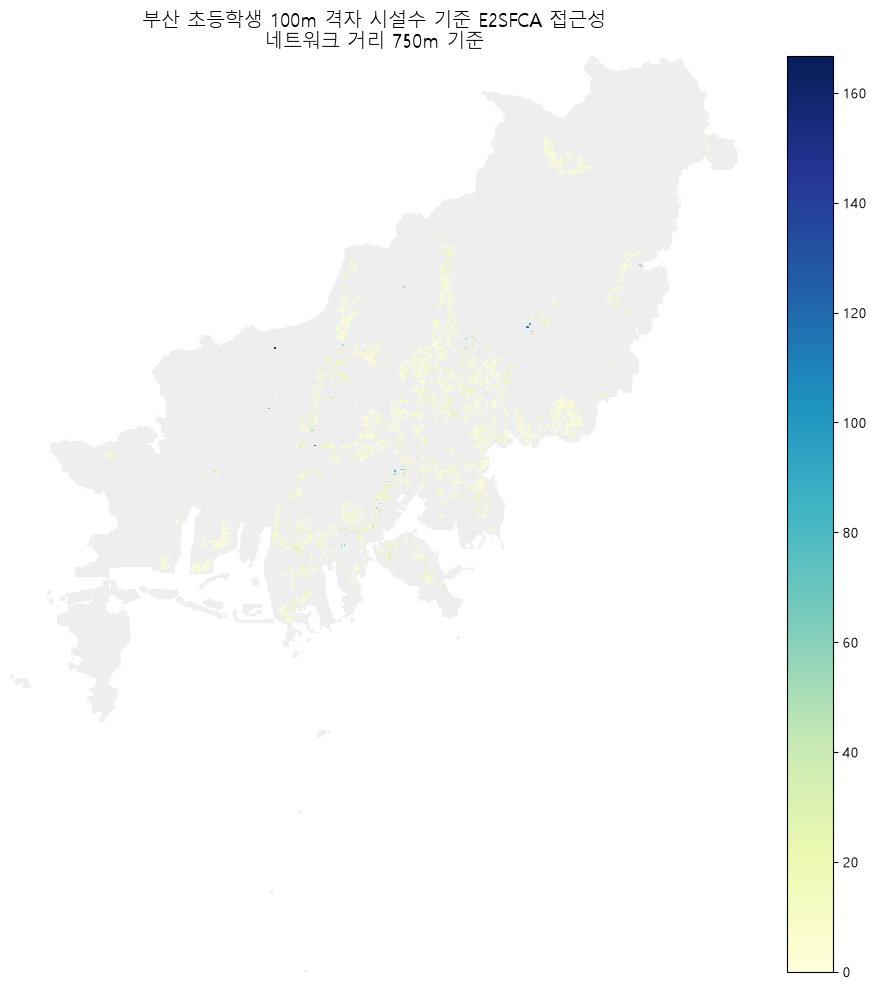

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    column="access_e2sfca_1000",
    cmap="YlGnBu",
    linewidth=0.05,
    edgecolor="#E6E6E6",
    legend=True,
    missing_kwds={
        "color": "#F2F2F2",
        "edgecolor": "#E6E6E6",
        "label": "계산 제외"
    }
)
'''
facility_gdf.plot(
    ax=ax,
    color="#E63946",
    markersize=5,
    marker="o",
    zorder=10,
    label="돌봄 관련 시설"
)
'''
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title(
    "부산 초등학생 100m 격자 시설수 기준 E2SFCA 접근성\n네트워크 거리 750m 기준",
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
'''
fig.savefig(
    "부산_시설수기준_E2SFCA_접근성지도.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
'''
plt.show()

위의 접근성 지도가 색이 연하고 가독성이 떨어져서

상위 5% 이상 값들은 다 진한 색으로 처리해봄



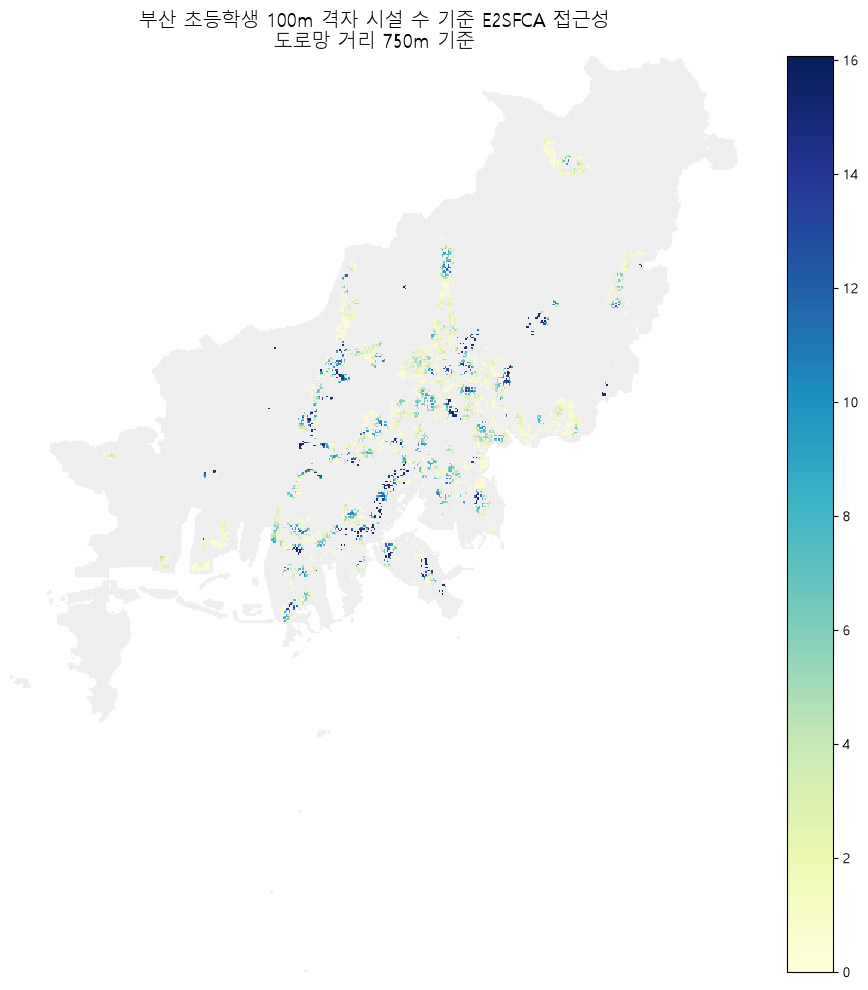

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))

analysis_mask = gdf[pop_col].notna() & (gdf[pop_col] > 0)

# 너무 큰 극단값 때문에 색이 연해지는 걸 막기 위해 95% 분위수를 최대색 기준으로 사용
vmax = gdf.loc[analysis_mask, "access_e2sfca_1000"].quantile(0.95)

gdf.plot(
    ax=ax,
    column="access_e2sfca_1000",
    cmap="YlGnBu",          # YlGnBu보다 더 진하고 직관적
    linewidth=0.03,
    edgecolor="#E6E6E6",
    legend=True,
    vmin=0,
    vmax=vmax,
    missing_kwds={
        "color": "#F2F2F2",
        "edgecolor": "#E6E6E6",
        "label": "초등학생 인구 없음 / 분석 제외"
    }
)
'''
facility_gdf.plot(
    ax=ax,
    color="black",
    markersize=4,
    marker="o",
    alpha=0.7,
    zorder=10,
    label="돌봄 관련 시설"
)
'''
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title(
    "부산 초등학생 100m 격자 시설 수 기준 E2SFCA 접근성\n도로망 거리 750m 기준",
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
'''
fig.savefig(
    "부산_시설수기준_E2SFCA_접근성지도_진하게.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
'''
plt.show()

## 13.시설부족지역 기준
* 초등학생 인구가 있는 격자만 분석 대상으로 사용
* 고수요 기준: 초등학생 인구 상위 25%
* 저접근성 기준: E2SFCA 접근성 하위 25%

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 초등학생 인구가 있는 격자만 분석 대상으로 사용
analysis_mask = gdf[pop_col].notna() & (gdf[pop_col] > 0)

# 접근성은 이미 11번에서
# 초등학생 인구 있는 격자: 0 또는 양수
# 초등학생 인구 없는 격자: NaN
# 상태로 만들어졌다고 가정

# 분석용 컬럼
gdf["access_for_gap"] = gdf["access_e2sfca_1000"]

# 기준값 계산
pop_q75 = gdf.loc[analysis_mask, pop_col].quantile(0.75)
acc_q25 = gdf.loc[analysis_mask, "access_for_gap"].quantile(0.25)

print("초등학생 인구 상위 25% 기준:", pop_q75)
print("접근성 하위 25% 기준:", acc_q25)

초등학생 인구 상위 25% 기준: 32.0
접근성 하위 25% 기준: 0.0


In [26]:

gdf["high_demand"] = False
gdf["low_access"] = False
gdf["shortage_area"] = False

gdf.loc[analysis_mask, "high_demand"] = gdf.loc[analysis_mask, pop_col] >= pop_q75
gdf.loc[analysis_mask, "low_access"] = gdf.loc[analysis_mask, "access_for_gap"] <= acc_q25

gdf.loc[analysis_mask, "shortage_area"] = (
    gdf.loc[analysis_mask, "high_demand"] &
    gdf.loc[analysis_mask, "low_access"]
)

print("분석 대상 격자 수:", analysis_mask.sum())
print("고수요 격자 수:", gdf["high_demand"].sum())
print("저접근성 격자 수:", gdf["low_access"].sum())
print("부족지역 격자 수:", gdf["shortage_area"].sum())

분석 대상 격자 수: 5539
고수요 격자 수: 1418
저접근성 격자 수: 1631
부족지역 격자 수: 555


In [27]:
gdf["gap_type"] = "분석 제외"

gdf.loc[analysis_mask & gdf["high_demand"] & gdf["low_access"], "gap_type"] = "고수요-저접근성"
gdf.loc[analysis_mask & gdf["high_demand"] & ~gdf["low_access"], "gap_type"] = "고수요-접근성양호"
gdf.loc[analysis_mask & ~gdf["high_demand"] & gdf["low_access"], "gap_type"] = "저수요-저접근성"
gdf.loc[analysis_mask & ~gdf["high_demand"] & ~gdf["low_access"], "gap_type"] = "저수요-접근성양호"

print(gdf["gap_type"].value_counts())

gap_type
분석 제외        76310
저수요-접근성양호     3045
저수요-저접근성      1076
고수요-접근성양호      863
고수요-저접근성       555
Name: count, dtype: int64


## 14.4유형 지도

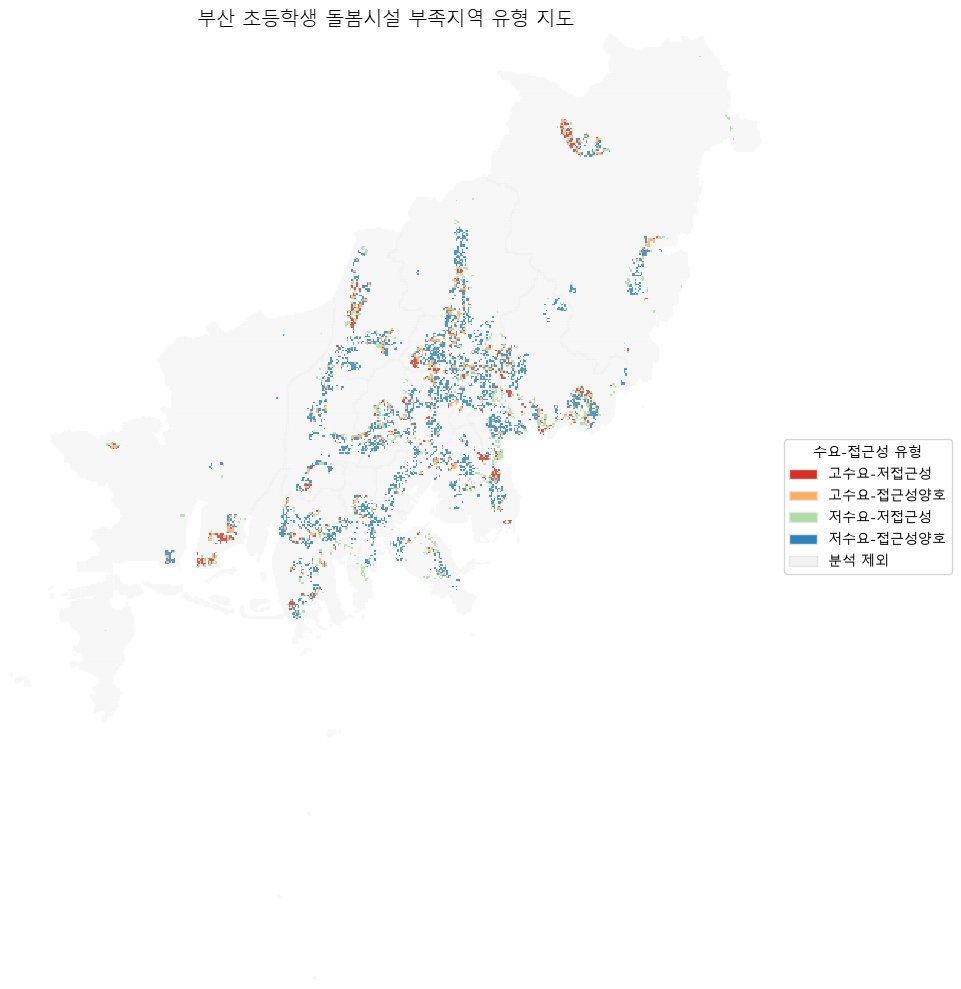

In [28]:
gap_colors = {
    "고수요-저접근성": "#D73027",     # 빨강
    "고수요-접근성양호": "#FDAE61",  # 주황
    "저수요-저접근성": "#ABDDA4",     # 연두
    "저수요-접근성양호": "#2B83BA",  # 파랑
    "분석 제외": "#F2F2F2"           # 회색
}

fig, ax = plt.subplots(figsize=(10, 10))

for typ in ["분석 제외", "저수요-접근성양호", "저수요-저접근성", "고수요-접근성양호", "고수요-저접근성"]:
    subset = gdf[gdf["gap_type"] == typ]

    if not subset.empty:
        subset.plot(
            ax=ax,
            color=gap_colors[typ],
            edgecolor="#E6E6E6",
            linewidth=0.03,
            alpha=0.85 if typ != "분석 제외" else 0.35
        )
'''
# 시설 점 보조 표시
facility_gdf.plot(
    ax=ax,
    color="black",
    markersize=4,
    marker="o",
    alpha=0.7,
    zorder=10,
    label="돌봄 관련 시설"
)
'''
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

legend_handles = [
    mpatches.Patch(facecolor=gap_colors["고수요-저접근성"], edgecolor="#E6E6E6", label="고수요-저접근성"),
    mpatches.Patch(facecolor=gap_colors["고수요-접근성양호"], edgecolor="#E6E6E6", label="고수요-접근성양호"),
    mpatches.Patch(facecolor=gap_colors["저수요-저접근성"], edgecolor="#E6E6E6", label="저수요-저접근성"),
    mpatches.Patch(facecolor=gap_colors["저수요-접근성양호"], edgecolor="#E6E6E6", label="저수요-접근성양호"),
    mpatches.Patch(facecolor=gap_colors["분석 제외"], edgecolor="#E6E6E6", label="분석 제외")
]

ax.legend(
    handles=legend_handles,
    title="수요-접근성 유형",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_title("부산 초등학생 돌봄시설 부족지역 유형 지도", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
fig.savefig("부산_돌봄시설_부족지역_4유형지도.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 15.고수요-저접근성 강조 지도

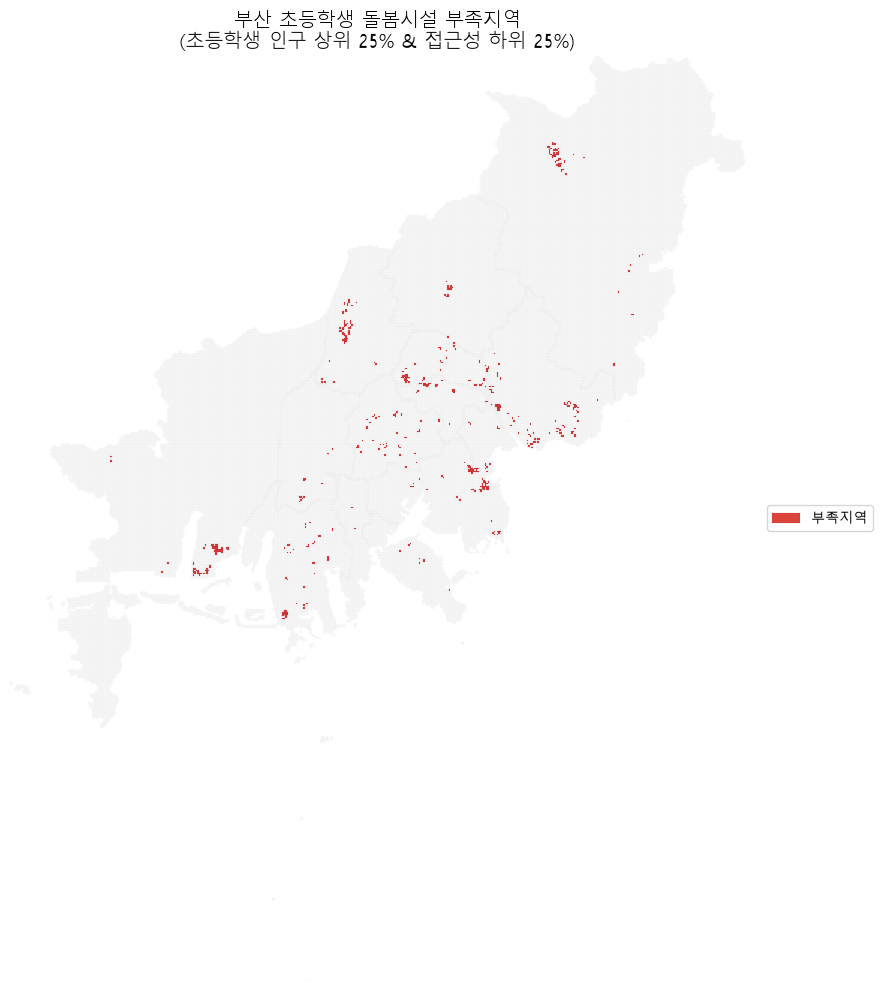

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    color="#F2F2F2",
    edgecolor="#E6E6E6",
    linewidth=0.03,
    alpha=0.5
)

gdf[gdf["shortage_area"]].plot(
    ax=ax,
    color="#D73027",
    edgecolor="#A50026",
    linewidth=0.08,
    alpha=0.9,
    label="부족지역"
)
'''
# 시설 점
facility_gdf.plot(
    ax=ax,
    color="black",
    markersize=4,
    marker="o",
    alpha=0.7,
    zorder=10,
    label="돌봄 관련 시설"
)
'''
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_title(
    "부산 초등학생 돌봄시설 부족지역\n(초등학생 인구 상위 25% & 접근성 하위 25%)",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
fig.savefig("부산_돌봄시설_부족지역_강조지도.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 사회·경제적 요인 분석: 비율 회귀로 수정

> **수정 및 보완 부분**  
> 기존 토빗 회귀는 `shortage_grid`가 0 이상의 이산형 개수 자료라는 점에서 표준 토빗의 검열 연속변수 가정과 맞지 않을 수도 있음. 따라서 행정동 면적과 격자 수의 차이를 통제할 수 있도록 종속변수를 **아동 거주 격자 중 잠재적 접근성 취약 격자의 비율**로 변경하고, 0~1 비율을 분석하는 **Fractional Logit(GLM Binomial-logit)**을 사용.

### 수정 워크플로우
1. 100m 격자를 행정동에 결합
2. 행정동별 아동 거주 격자 수와 잠재적 접근성 취약 격자 수를 집계
3. `취약 격자 비율 = 취약 격자 수 / 아동 거주 격자 수`를 계산
4. 사회·경제 변수는 행정동 규모 차이를 줄이기 위해 밀도·비율 변수로 변환
5. 상관계수와 VIF로 다중공선성을 확인
6. Fractional Logit을 주 모형으로 추정
7. Random Forest 회귀를 보조 모형으로 비교
8. 취약성 보조지수는 산식과 표준화 방향을 명시하여 별도로 산출

## 1. 행정동별 분석 기준 데이터 만들기

- **Input:** 100m 격자별 아동 인구, E2SFCA 접근성, 잠재적 접근성 취약 여부, 행정동 경계
- **Output:** 행정동별 아동 거주 격자 수, 취약 격자 수, 취약 격자 비율, 아동 인구, 평균 접근성

`gap_type == "고수요-저접근성"`은 기존 분석과의 연결을 위해 사용하지만, 이후 해석에서는 단정적인 ‘돌봄공백’ 대신 **잠재적 접근성 취약 격자**라고 표현

In [30]:
import numpy as np
import pandas as pd
import geopandas as gpd

# 수정 및 보완 부분 - 행정동 면적과 격자 수 차이의 영향을 줄이기 위해
# 단순 취약 격자 '개수'뿐 아니라 아동 거주 격자 중 취약 격자의 '비율'을 계산합니다.

dong = gpd.read_file("읍면동/BND_ADM_DONG_PG.shp").to_crs(gdf.crs)
dong["ADM_CD"] = dong["ADM_CD"].astype(str)

# 각 행정동 면적(km²): 이후 인구·학원 밀도 계산에 사용합니다.
dong["area_km2"] = dong.geometry.area / 1_000_000

# 격자 폴리곤의 중심점을 행정동에 귀속합니다.
grid_point = gdf.copy()
grid_point["geometry"] = grid_point.geometry.centroid

grid_dong = gpd.sjoin(
    grid_point,
    dong[["ADM_CD", "ADM_NM", "area_km2", "geometry"]],
    how="left",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

# 아동이 실제 거주하는 격자만 별도로 표시합니다.
grid_dong["is_populated_grid"] = pd.to_numeric(
    grid_dong[pop_col], errors="coerce"
).fillna(0).gt(0)

# 기존 분류 결과 중 잠재적 접근성 취약 격자를 표시합니다.
# shortage_area가 있으면 우선 사용하고, 없으면 gap_type으로 안전하게 대체합니다.
if "shortage_area" in grid_dong.columns:
    grid_dong["is_vulnerable_grid"] = grid_dong["shortage_area"].fillna(False).astype(bool)
elif "gap_type" in grid_dong.columns:
    grid_dong["is_vulnerable_grid"] = grid_dong["gap_type"].eq("고수요-저접근성")
else:
    raise KeyError("'shortage_area' 또는 'gap_type' 컬럼이 필요합니다.")

# 아동이 없는 격자는 취약 비율의 분모·분자에서 제외합니다.
grid_dong["vulnerable_populated_grid"] = (
    grid_dong["is_populated_grid"] & grid_dong["is_vulnerable_grid"]
)

agg_dict = {
    "access_mean": ("access_e2sfca_1000", "mean"),
    "child_pop": (pop_col, "sum"),
    "populated_grid_count": ("is_populated_grid", "sum"),
    "vulnerable_grid_count": ("vulnerable_populated_grid", "sum"),
    "area_km2": ("area_km2", "first")
}

dong_access = (
    grid_dong.groupby(["ADM_CD", "ADM_NM"], as_index=False)
    .agg(**agg_dict)
)

# 핵심 종속변수: 0~1 범위의 연속 비율
# 분모가 0인 행정동은 분석할 수 없으므로 NaN 처리합니다.
dong_access["vulnerable_grid_ratio"] = np.where(
    dong_access["populated_grid_count"] > 0,
    dong_access["vulnerable_grid_count"] / dong_access["populated_grid_count"],
    np.nan
)

# 기존 후속 코드와의 호환성을 위해 기존 변수명도 유지합니다.
dong_access["shortage_grid"] = dong_access["vulnerable_grid_count"]

print(dong_access[[
    "ADM_NM", "child_pop", "populated_grid_count",
    "vulnerable_grid_count", "vulnerable_grid_ratio"
]].describe())

dong_access.head()

         child_pop  populated_grid_count  vulnerable_grid_count  \
count   221.000000            221.000000             221.000000   
mean    636.751131             25.058824               2.506787   
std     850.355827             23.224814               5.869505   
min       0.000000              0.000000               0.000000   
25%     126.000000              9.000000               0.000000   
50%     407.000000             20.000000               0.000000   
75%     809.000000             36.000000               2.000000   
max    7692.000000            209.000000              49.000000   

       vulnerable_grid_ratio  
count             203.000000  
mean                0.065799  
std                 0.102168  
min                 0.000000  
25%                 0.000000  
50%                 0.000000  
75%                 0.092330  
max                 0.444444  


,ADM_CD,ADM_NM,access_mean,child_pop,populated_grid_count,vulnerable_grid_count,area_km2,vulnerable_grid_ratio,shortage_grid
0,21010510,중앙동,3.492204,18.0,2,0,0.815297,0.0,0
1,21010520,동광동,2.304810,21.0,2,0,0.162081,0.0,0
2,21010530,대청동,20.083552,89.0,9,0,0.356154,0.0,0
3,21010540,보수동,10.921139,255.0,20,0,0.413385,0.0,0
4,21010560,부평동,18.705658,36.0,4,0,0.224712,0.0,0


## 2. 지가 데이터 정리

In [31]:
# 행정동 및 개별공시지가 shp 불러오기
dong_gdf = gpd.read_file("읍면동/BND_ADM_DONG_PG.shp", encoding="cp949")
land_gdf = gpd.read_file("개별공시지가/AL_D150_26_20260526.shp", encoding="cp949")

# 좌표계 통일
land_gdf = land_gdf.to_crs(dong_gdf.crs)

# 지가 컬럼 숫자형 변환
land_gdf["A9"] = pd.to_numeric(land_gdf["A9"], errors="coerce")

# 지가 필지와 행정동 공간결합
land_joined = gpd.sjoin(
    land_gdf,
    dong_gdf[["ADM_CD", "ADM_NM", "geometry"]],
    how="left",
    predicate="intersects"
)

# 행정동별 지가 요약
land_price = (
    land_joined
    .groupby(["ADM_CD", "ADM_NM"], as_index=False)
    .agg(
        mean_land_price=("A9", "mean"),
        median_land_price=("A9", "median"),
        land_count=("A9", "count")
    )
)

import os
land_price.to_csv("행정동별_지가.csv", index=False, encoding="utf-8-sig")
print("저장 완료:", os.path.exists("행정동별_지가.csv"))
land_price.head()

저장 완료: True


,ADM_CD,ADM_NM,mean_land_price,median_land_price,land_count
0,21010510,중앙동,4.491129e+06,4578000.0,1135
1,21010520,동광동,1.768259e+06,1037000.0,1479
2,21010530,대청동,1.269732e+06,775700.0,2613
3,21010540,보수동,1.084552e+06,671800.0,3719
4,21010560,부평동,5.232802e+06,4002500.0,1858


## 3. 학원 데이터 정리

In [32]:
academy_raw = pd.read_csv(
    "부산광역시교육청 학원 및 교습소 현황_20260615.csv",
    encoding="utf-8-sig",
    low_memory=False
)

# 주소에서 시군구 추출
academy_raw["시군구"] = academy_raw["위치"].str.extract(
    r"부산광역시\s+(\S+(?:구|군))"
)

# 괄호 안의 법정동/읍/면/리 추출
academy_raw["읍면동"] = academy_raw["위치"].str.extract(
    r"\(([가-힣]+(?:읍|면|동\d?가?|동|리))\)"
)

# 같은 학원이 여러 교습과목으로 반복될 수 있으므로 중복 제거
academy_unique = academy_raw.drop_duplicates(
    subset=["학원명", "위치"]
).copy()

academy_unique = academy_unique.dropna(subset=["시군구", "읍면동"]).copy()

academy = (
    academy_unique
    .groupby(["시군구", "읍면동"], as_index=False)
    .agg(academy_count=("학원명", "count"))
)

academy.to_csv("행정동별_학원수.csv", index=False, encoding="utf-8-sig")
academy.head()

,시군구,읍면동,academy_count
0,강서구,명지동,300
1,강서구,송정동,1
2,강서구,신호동,22
3,강서구,지사동,5
4,금정구,구서동,189


## 4. 학원 수를 행정동 접근성 자료에 결합

In [33]:
import pandas as pd
import re

academy_dong_set = set(academy["읍면동"].dropna().unique())

def make_academy_match_name(adm_nm):
    # 행정동명을 학원 주소에서 추출한 법정동명과 최대한 맞추는 함수

    if adm_nm in academy_dong_set:
        return adm_nm

    special_map = {
        "동대신1동": "동대신동1가",
        "동대신2동": "동대신동2가",
        "동대신3동": "동대신동3가",
        "서대신1동": "서대신동1가",
        "서대신2동": "서대신동2가",
        "서대신3동": "서대신동3가",
        "서대신4동": "서대신동4가",
        "중앙동": "중앙동4가",
        "대청동": "대청동4가",
        "보수동": "보수동1가",
        "부평동": "부평동1가",
        "남포동": "남포동6가",
        "영선1동": "영선동1가",
        "영선2동": "영선동2가",
        "봉래1동": "봉래동3가",
        "봉래2동": "봉래동4가",
    }

    if adm_nm in special_map:
        return special_map[adm_nm]

    # 예: 화명1동 → 화명동, 광안4동 → 광안동
    candidate = re.sub(r"(.+?)\d+동$", r"\1동", adm_nm)

    if candidate in academy_dong_set:
        return candidate

    return adm_nm


dong_access["academy_match_dong"] = dong_access["ADM_NM"].apply(make_academy_match_name)

model_df = dong_access.merge(
    academy[["읍면동", "academy_count"]],
    left_on="academy_match_dong",
    right_on="읍면동",
    how="left"
)

model_df["academy_count"] = model_df["academy_count"].fillna(0)

model_df[["ADM_CD", "ADM_NM", "academy_match_dong", "academy_count"]].head()

,ADM_CD,ADM_NM,academy_match_dong,academy_count
0,21010510,중앙동,중앙동4가,6.0
1,21010520,동광동,동광동,0.0
2,21010530,대청동,대청동4가,5.0
3,21010540,보수동,보수동1가,4.0
4,21010560,부평동,부평동1가,1.0


## 5. 부산 행정동만 남기기

In [34]:
model_df["ADM_CD"] = model_df["ADM_CD"].astype(str)

model_df_busan = model_df[
    model_df["ADM_CD"].str.startswith("21")
].copy()

print("부산 행정동 수:", len(model_df_busan))
print("학원 수 0인 행정동 수:", (model_df_busan["academy_count"] == 0).sum())


부산 행정동 수: 207
학원 수 0인 행정동 수: 20


## 6. 기초생활보장 수급자 데이터 정리

In [35]:
welfare_raw = pd.read_csv(
    "부산광역시_기초생활보장 수급자 읍면동 현황_20231231.csv",
    encoding="cp949"
)

# 2023년 자료만 사용
welfare_2023 = welfare_raw[welfare_raw["연도"] == 2023].copy()

# 구 전체 합계 행 제거
welfare_2023 = welfare_2023[
    welfare_2023["시군구"] != welfare_2023["읍면동"]
].copy()

# 명칭 변경 반영
welfare_2023["읍면동"] = welfare_2023["읍면동"].replace({
    "일광면": "일광읍"
})

welfare_cols = [
    "일반수급자 수급권자수",
    "조건부수급자 수급권자수",
    "특례수급자 수급권자수",
    "기타 수급권자수",
    "시설수급자 수급권자수"
]

for col in welfare_cols:
    welfare_2023[col] = pd.to_numeric(welfare_2023[col], errors="coerce").fillna(0)

welfare_2023["welfare_count"] = welfare_2023[welfare_cols].sum(axis=1)

welfare = welfare_2023[["시군구", "읍면동", "welfare_count"]].copy()
welfare.to_csv("행정동별_기초수급자수.csv", index=False, encoding="utf-8-sig")

welfare.head()

,시군구,읍면동,welfare_count
446,중구,중앙동,182
447,중구,동광동,464
448,중구,대청동,714
449,중구,보수동,1209
450,중구,부평동,543


## 7. 기초수급자 데이터에 행정동 코드 붙이기

In [36]:
dong_code_table = dong_access[["ADM_CD", "ADM_NM"]].copy()
dong_code_table = dong_code_table.rename(columns={"ADM_NM": "읍면동"})
dong_code_table["ADM_CD"] = dong_code_table["ADM_CD"].astype(str)

welfare_with_code = welfare.merge(
    dong_code_table,
    on="읍면동",
    how="left"
)

print("ADM_CD 안 붙은 기초수급자 행 수:", welfare_with_code["ADM_CD"].isna().sum())

welfare_with_code.to_csv(
    "행정동별_기초수급자수_ADM_CD포함.csv",
    index=False,
    encoding="utf-8-sig"
)

welfare_with_code.head()


ADM_CD 안 붙은 기초수급자 행 수: 0


,시군구,읍면동,welfare_count,ADM_CD
0,중구,중앙동,182,21010510
1,중구,동광동,464,21010520
2,중구,대청동,714,21010530
3,중구,보수동,1209,21010540
4,중구,부평동,543,21010560


## 8. 최종 데이터 결합

## 8. 최종 데이터 결합 및 규모 보정 변수 생성

> **수정 및 보완 부분**  
> 행정동마다 면적과 아동 수가 다르므로 원자료 개수를 그대로 비교하지 않음. 학원 수는 면적당 밀도, 기초수급자 수는 아동 1,000명당 비율, 아동 인구는 면적당 밀도로 변환.

In [37]:
import os
import numpy as np
import pandas as pd

land_price = pd.read_csv("행정동별_지가.csv", encoding="utf-8-sig")

for frame in (model_df_busan, land_price, welfare_with_code):
    frame["ADM_CD"] = frame["ADM_CD"].astype(str)

model_df_final = model_df_busan.merge(
    land_price[["ADM_CD", "mean_land_price", "median_land_price", "land_count"]],
    on="ADM_CD", how="left"
).merge(
    welfare_with_code[["ADM_CD", "welfare_count"]],
    on="ADM_CD", how="left"
)

required_cols = [
    "vulnerable_grid_ratio", "populated_grid_count", "child_pop", "area_km2",
    "academy_count", "welfare_count", "mean_land_price"
]
for col in required_cols:
    model_df_final[col] = pd.to_numeric(model_df_final[col], errors="coerce")

# 수정 및 보완 부분 - 규모가 큰 행정동에서 개수 변수가 자연히 커지는 문제를 완화합니다.
model_df_final["child_density_km2"] = (
    model_df_final["child_pop"] / model_df_final["area_km2"].replace(0, np.nan)
)
model_df_final["academy_density_km2"] = (
    model_df_final["academy_count"] / model_df_final["area_km2"].replace(0, np.nan)
)
model_df_final["welfare_per_1000_child"] = (
    model_df_final["welfare_count"] / model_df_final["child_pop"].replace(0, np.nan) * 1000
)

model_df_final_clean = model_df_final.dropna(subset=required_cols + [
    "child_density_km2", "academy_density_km2", "welfare_per_1000_child"
]).copy()
model_df_final_clean = model_df_final_clean[
    (model_df_final_clean["child_pop"] > 0) &
    (model_df_final_clean["populated_grid_count"] > 0) &
    model_df_final_clean["vulnerable_grid_ratio"].between(0, 1)
].copy()

output_csv = "비율회귀용_행정동별_최종데이터_clean.csv"
model_df_final_clean.to_csv(output_csv, index=False, encoding="utf-8-sig")

print("최종 분석 행정동 수:", len(model_df_final_clean))
print("취약 격자 비율 범위:", model_df_final_clean["vulnerable_grid_ratio"].min(), "~", model_df_final_clean["vulnerable_grid_ratio"].max())
print("저장 완료:", os.path.exists(output_csv))
model_df_final_clean.head()

최종 분석 행정동 수: 204
취약 격자 비율 범위: 0.0 ~ 0.4444444444444444
저장 완료: True


,ADM_CD,ADM_NM,access_mean,child_pop,populated_grid_count,vulnerable_grid_count,area_km2,vulnerable_grid_ratio,shortage_grid,academy_match_dong,읍면동,academy_count,mean_land_price,median_land_price,land_count,welfare_count,child_density_km2,academy_density_km2,welfare_per_1000_child
0,21010510,중앙동,3.492204,18.0,2,0,0.815297,0.0,0,중앙동4가,중앙동4가,6.0,4.491129e+06,4578000.0,1135,182.0,22.077840,7.359280,10111.111111
1,21010520,동광동,2.304810,21.0,2,0,0.162081,0.0,0,동광동,NaN,0.0,1.768259e+06,1037000.0,1479,464.0,129.565032,0.000000,22095.238095
2,21010530,대청동,20.083552,89.0,9,0,0.356154,0.0,0,대청동4가,대청동4가,5.0,1.269732e+06,775700.0,2613,714.0,249.892039,14.038879,8022.471910
3,21010540,보수동,10.921139,255.0,20,0,0.413385,0.0,0,보수동1가,보수동1가,4.0,1.084552e+06,671800.0,3719,1209.0,616.858680,9.676215,4741.176471
4,21010560,부평동,18.705658,36.0,4,0,0.224712,0.0,0,부평동1가,부평동1가,1.0,5.232802e+06,4002500.0,1858,543.0,160.205169,4.450144,15083.333333


## 2. 설명변수 변환 및 상관·다중공선성 점검

- 지가와 밀도 변수는 오른쪽 꼬리가 길 수 있으므로 `log1p` 변환.
- 종속변수에 이미 취약 격자 **비율**이 사용되므로, 단순 아동 인구 개수 대신 **아동 밀도**를 통제변수로 사용.
- 절대 상관계수가 지나치게 높거나 VIF가 큰 변수는 결과 해석 시 주의!

In [38]:
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 수정 및 보완 부분 - 원자료 개수 대신 규모 보정 및 로그 변환 변수를 사용합니다.
model_df_final_clean["ln_child_density"] = np.log1p(model_df_final_clean["child_density_km2"])
model_df_final_clean["ln_academy_density"] = np.log1p(model_df_final_clean["academy_density_km2"])
model_df_final_clean["ln_welfare_rate"] = np.log1p(model_df_final_clean["welfare_per_1000_child"])
model_df_final_clean["ln_land_price"] = np.log1p(model_df_final_clean["mean_land_price"])

feature_cols = [
    "ln_child_density", "ln_academy_density",
    "ln_welfare_rate", "ln_land_price"
]

corr_table = model_df_final_clean[["vulnerable_grid_ratio"] + feature_cols].corr()
print("상관계수표")
display(corr_table.round(3))

X_vif = sm.add_constant(model_df_final_clean[feature_cols])
vif_table = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print("VIF 점검표")
display(vif_table.round(3))

상관계수표


,vulnerable_grid_ratio,ln_child_density,ln_academy_density,ln_welfare_rate,ln_land_price
vulnerable_grid_ratio,1.000,0.307,0.177,-0.512,0.078
ln_child_density,0.307,1.000,0.675,-0.552,0.546
ln_academy_density,0.177,0.675,1.000,-0.291,0.476
ln_welfare_rate,-0.512,-0.552,-0.291,1.000,-0.183
ln_land_price,0.078,0.546,0.476,-0.183,1.000


VIF 점검표


,variable,VIF
0,const,689.065
1,ln_child_density,2.846
2,ln_academy_density,1.915
3,ln_welfare_rate,1.496
4,ln_land_price,1.502


## 3. Fractional Logit 회귀

Fractional Logit은 종속변수가 0과 1을 포함하는 비율일 때 사용할 수 있는 GLM

- **Input(X):** 아동 밀도, 학원 밀도, 아동 1,000명당 기초수급자 수, 평균 지가
- **Output(Y):** 아동 거주 격자 중 잠재적 접근성 취약 격자 비율
- 계수가 양수이면 해당 변수가 증가할수록 취약 격자 비율이 높아지는 방향, 음수이면 낮아지는 방향을 뜻함.
- 계수 자체는 비율의 직접 변화량이 아니라 log-odds 척도이므로 평균한계효과를 함께 확인.

In [39]:
import statsmodels.api as sm

# 수정 및 보완 부분 - 토빗 회귀를 제거하고 0~1 비율에 적합한 Fractional Logit을 적용합니다.
y_frac = model_df_final_clean["vulnerable_grid_ratio"].astype(float)
X_frac = sm.add_constant(model_df_final_clean[feature_cols].astype(float), has_constant="add")

fractional_logit_model = sm.GLM(
    y_frac,
    X_frac,
    family=sm.families.Binomial(link=sm.families.links.Logit())
)

# 행정동 단위 이분산 가능성을 고려해 HC3 강건 표준오차를 사용합니다.
fractional_logit_result = fractional_logit_model.fit(cov_type="HC3")
print(fractional_logit_result.summary())

# 평균한계효과: 각 설명변수가 1단위 증가할 때 예측 비율이 평균적으로 얼마나 변하는지 계산합니다.
predicted_p = fractional_logit_result.predict(X_frac)
beta = fractional_logit_result.params
marginal_effects = beta * np.mean(predicted_p * (1 - predicted_p))

fractional_effect_table = pd.DataFrame({
    "coefficient": beta,
    "robust_p_value": fractional_logit_result.pvalues,
    "average_marginal_effect": marginal_effects
}).drop(index="const", errors="ignore")

display(fractional_effect_table.round(4))

                   Generalized Linear Model Regression Results                   
Dep. Variable:     vulnerable_grid_ratio   No. Observations:                  204
Model:                               GLM   Df Residuals:                      199
Model Family:                   Binomial   Df Model:                            4
Link Function:                     Logit   Scale:                          1.0000
Method:                             IRLS   Log-Likelihood:                -34.631
Date:                   Sun, 19 Jul 2026   Deviance:                       20.335
Time:                           20:34:41   Pearson chi2:                     25.8
No. Iterations:                        7   Pseudo R-squ. (CS):            0.04457
Covariance Type:                     HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const 

,coefficient,robust_p_value,average_marginal_effect
ln_child_density,0.3958,0.0539,0.0229
ln_academy_density,-0.0058,0.9467,-0.0003
ln_welfare_rate,-0.4750,0.0007,-0.0275
ln_land_price,-0.2696,0.3996,-0.0156


## 4. 트리 기반 회귀 보조 분석

> **수정 및 보완 부분**  
> 선형적인 logit 관계만으로 설명되지 않는 비선형성과 변수 간 상호작용을 확인하기 위해 Random Forest 회귀를 보조적으로 사용. 표본 수가 크지 않으므로 성능 수치는 탐색적 비교로만 해석.

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

X_tree = model_df_final_clean[feature_cols].astype(float)
y_tree = model_df_final_clean["vulnerable_grid_ratio"].astype(float)

n_splits = min(5, len(model_df_final_clean))
if n_splits < 2:
    raise ValueError("교차검증을 위해 최소 2개 이상의 행정동이 필요합니다.")

cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
rf_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=1
)

rf_oof_pred = cross_val_predict(rf_model, X_tree, y_tree, cv=cv, n_jobs=1)
rf_oof_pred = np.clip(rf_oof_pred, 0, 1)

print("Random Forest 교차검증 성능")
print("MAE :", round(mean_absolute_error(y_tree, rf_oof_pred), 4))
print("RMSE:", round(mean_squared_error(y_tree, rf_oof_pred) ** 0.5, 4))
print("R²  :", round(r2_score(y_tree, rf_oof_pred), 4))

rf_model.fit(X_tree, y_tree)
perm = permutation_importance(
    rf_model, X_tree, y_tree,
    n_repeats=30, random_state=42, scoring="neg_mean_absolute_error"
)
rf_importance = pd.DataFrame({
    "variable": feature_cols,
    "permutation_importance": perm.importances_mean
}).sort_values("permutation_importance", ascending=False)
display(rf_importance)

Random Forest 교차검증 성능
MAE : 0.0583
RMSE: 0.0858
R²  : 0.2875


,variable,permutation_importance
2,ln_welfare_rate,0.046291
3,ln_land_price,0.011658
0,ln_child_density,0.007191
1,ln_academy_density,0.005469


## 5. 사회·경제적 변수와 취약 비율의 공간 분포

지도는 5분위 범주 대신 **연속형 색상척도**로 표현. 범례에는 실제 최솟값과 최댓값이 표시되므로 구간 기준이 불명확해지는 문제를 줄일 수 있음.

In [41]:
# 지도용 GeoDataFrame 생성
# 수정 및 보완 부분 - 행정동 코드를 문자형으로 통일하고 중복 컬럼을 방지합니다.
dong_gdf = dong.copy()
dong_gdf["ADM_CD"] = dong_gdf["ADM_CD"].astype(str)
model_df_final_clean["ADM_CD"] = model_df_final_clean["ADM_CD"].astype(str)

map_gdf = dong_gdf.merge(
    model_df_final_clean.drop(columns="geometry", errors="ignore"),
    on=["ADM_CD", "ADM_NM"], how="left"
)
busan_map_gdf = map_gdf[map_gdf["ADM_CD"].str.startswith("21")].copy()
map_gdf.head()

,BASE_DATE,ADM_CD,ADM_NM,geometry,area_km2_x,access_mean,child_pop,populated_grid_count,vulnerable_grid_count,area_km2_y,...,median_land_price,land_count,welfare_count,child_density_km2,academy_density_km2,welfare_per_1000_child,ln_child_density,ln_academy_density,ln_welfare_rate,ln_land_price
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1...",1.157671,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1...",1.477188,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19...",2.273287,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1...",8.940413,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1...",0.369245,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


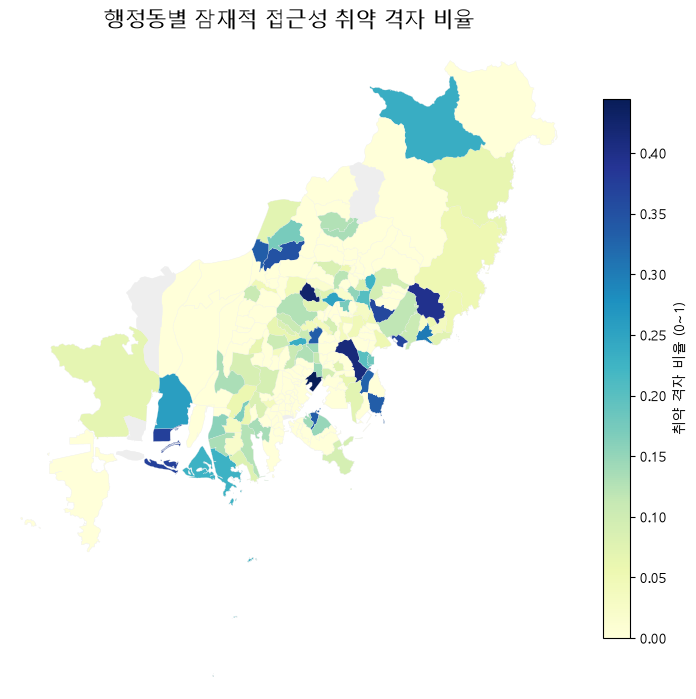

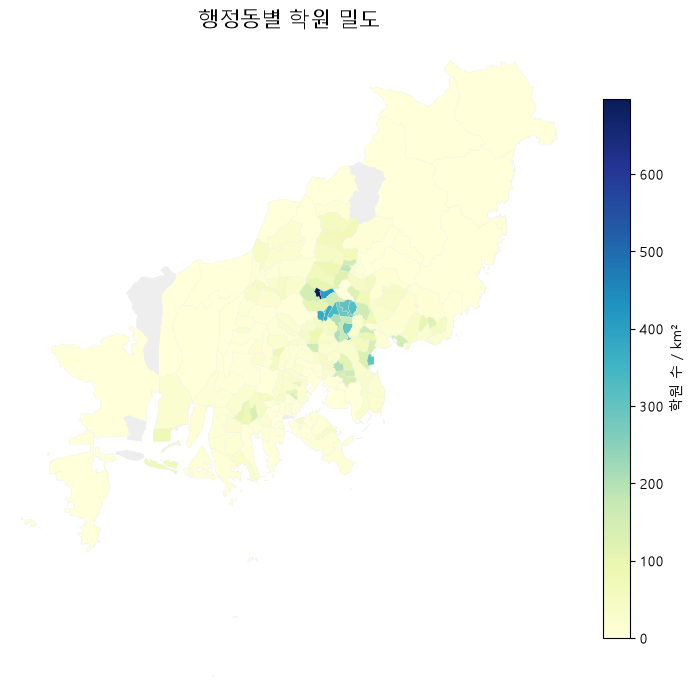

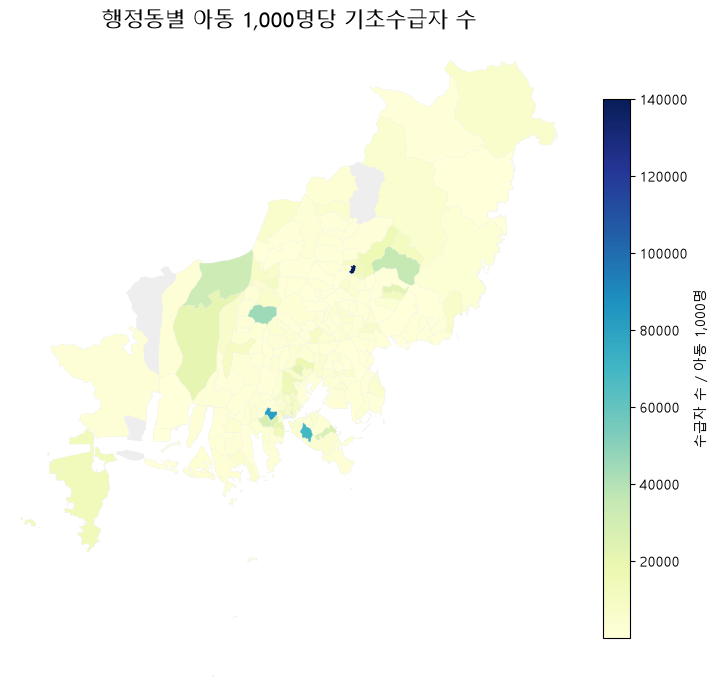

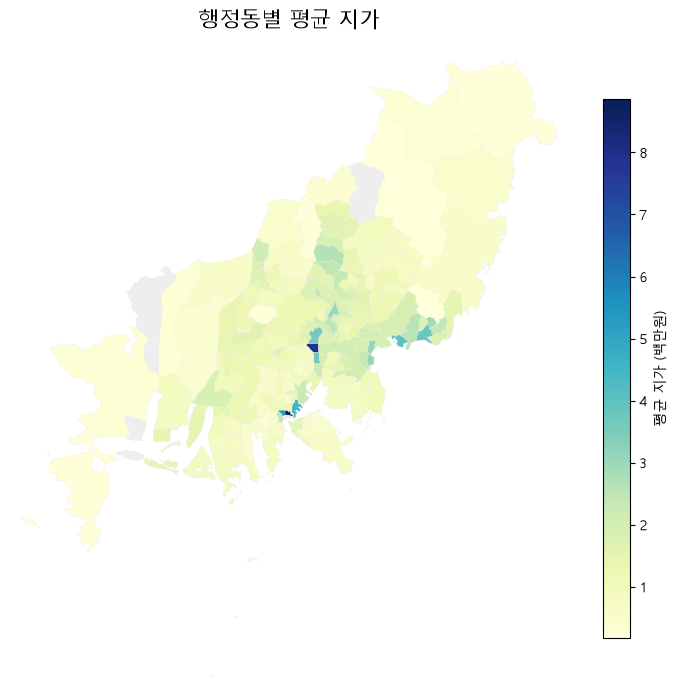

In [42]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

def plot_continuous_dong_map(gdf_map, column, title, filename, label):
    """행정동 연속형 값을 동일한 형식으로 지도화하는 함수입니다."""
    fig, ax = plt.subplots(figsize=(9, 10))
    gdf_map.plot(ax=ax, color="#eeeeee", edgecolor="#f5f5f5", linewidth=0.2)
    gdf_map.plot(
        column=column, cmap="YlGnBu", legend=True,
        edgecolor="#f2f2f2", linewidth=0.15, ax=ax,
        missing_kwds={"color": "#eeeeee", "label": "자료 없음"},
        legend_kwds={"label": label, "shrink": 0.7}
    )
    minx, miny, maxx, maxy = gdf_map.total_bounds
    ax.set_xlim(minx - (maxx-minx)*0.02, maxx + (maxx-minx)*0.02)
    ax.set_ylim(miny - (maxy-miny)*0.02, maxy + (maxy-miny)*0.02)
    ax.set_title(title, fontsize=15, pad=15)
    ax.set_axis_off(); ax.set_aspect("equal")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# 수정 및 보완 부분 - 5분위 구간 대신 연속형 히트맵으로 표현합니다.
plot_continuous_dong_map(busan_map_gdf, "vulnerable_grid_ratio",
    "행정동별 잠재적 접근성 취약 격자 비율",
    "행정동별_잠재적접근성취약격자비율.png", "취약 격자 비율 (0~1)")
plot_continuous_dong_map(busan_map_gdf, "academy_density_km2",
    "행정동별 학원 밀도", "행정동별_학원밀도.png", "학원 수 / km²")
plot_continuous_dong_map(busan_map_gdf, "welfare_per_1000_child",
    "행정동별 아동 1,000명당 기초수급자 수",
    "행정동별_기초수급자비율.png", "수급자 수 / 아동 1,000명")

busan_map_gdf["mean_land_price_million"] = busan_map_gdf["mean_land_price"] / 1_000_000
plot_continuous_dong_map(busan_map_gdf, "mean_land_price_million",
    "행정동별 평균 지가", "행정동별_평균지가.png", "평균 지가 (백만원)")

## 6. 사회·경제적 취약성 보조지수

이 지수는 회귀모형의 종속변수와 별개의 **정책 우선순위 참고용 합성지수**

- 표준화: 각 변수의 행정동 내 백분위 순위(`rank(pct=True)`, 0~1)
- 취약 방향: 취약 격자 비율↑, 기초수급자 비율↑, 학원 밀도↓, 평균 지가↓
- 가중치: 근거가 없는 임의 가중을 피하기 위해 동일 가중치 25% 적용

지가와 학원은 돌봄을 직접 대체한다고 단정하지 않고, 지역의 민간·경제적 자원 여건을 나타내는 보조지표로만 사용

In [43]:
# 수정 및 보완 부분 - MinMax 합산에서 백분위 순위 기반 동일가중 지수로 변경하고,
# 이전에 빠져 있던 평균 지가를 포함합니다.
score_df = model_df_final_clean.copy()
score_df["vulnerable_ratio_pct"] = score_df["vulnerable_grid_ratio"].rank(pct=True)
score_df["welfare_rate_pct"] = score_df["welfare_per_1000_child"].rank(pct=True)
score_df["low_academy_pct"] = 1 - score_df["academy_density_km2"].rank(pct=True)
score_df["low_land_price_pct"] = 1 - score_df["mean_land_price"].rank(pct=True)

score_df["socio_vulnerability"] = score_df[[
    "vulnerable_ratio_pct", "welfare_rate_pct",
    "low_academy_pct", "low_land_price_pct"
]].mean(axis=1)

model_df_final_clean = model_df_final_clean.drop(
    columns=["socio_vulnerability"], errors="ignore"
).merge(
    score_df[["ADM_CD", "socio_vulnerability"]], on="ADM_CD", how="left"
)

map_gdf = dong_gdf.merge(
    model_df_final_clean.drop(columns="geometry", errors="ignore"),
    on=["ADM_CD", "ADM_NM"], how="left"
)
busan_map_gdf = map_gdf[map_gdf["ADM_CD"].str.startswith("21")].copy()

display(model_df_final_clean[[
    "ADM_NM", "vulnerable_grid_ratio", "welfare_per_1000_child",
    "academy_density_km2", "mean_land_price", "socio_vulnerability"
]].sort_values("socio_vulnerability", ascending=False).head(10))

,ADM_NM,vulnerable_grid_ratio,welfare_per_1000_child,academy_density_km2,mean_land_price,socio_vulnerability
37,청학1동,0.333333,5206.349206,15.512688,510505.027322,0.805760
97,금곡동,0.071429,5664.735099,1.489168,529065.590191,0.800858
38,청학2동,0.148148,3016.528926,6.618733,541222.662741,0.779412
15,아미동,0.000000,80705.882353,0.000000,559859.480623,0.777574
160,대저2동,0.000000,21076.923077,0.000000,447679.459730,0.775123
43,봉래2동,0.142857,2464.150943,1.416677,600219.977703,0.774510
16,초장동,0.000000,25032.258065,0.000000,534380.909322,0.772672
163,가덕도동,0.000000,13562.500000,0.000000,258960.653568,0.771446
42,신선동,0.000000,68842.105263,0.000000,587519.130187,0.771446
159,대저1동,0.000000,32600.000000,0.000000,638542.420506,0.761642


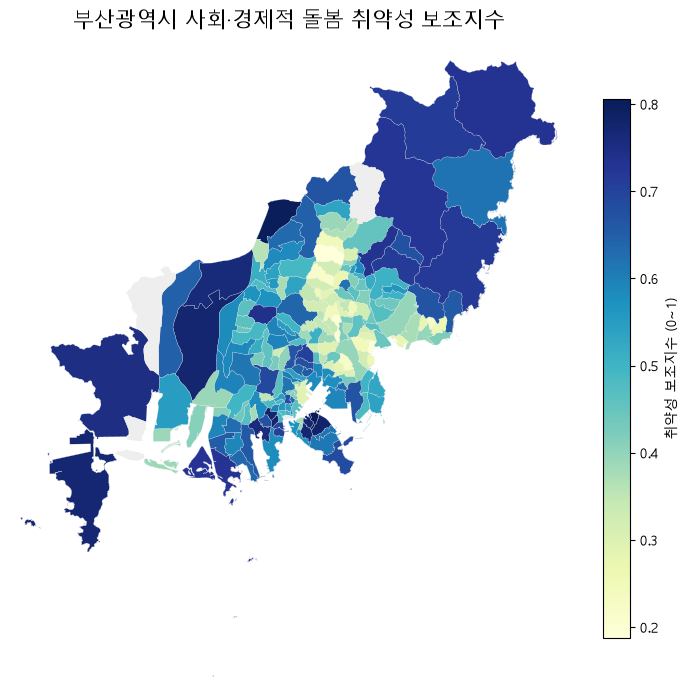

상위 25% 기준값: 0.6196
상위 25% 행정동 수: 52


In [44]:
plot_continuous_dong_map(
    busan_map_gdf, "socio_vulnerability",
    "부산광역시 사회·경제적 돌봄 취약성 보조지수",
    "부산광역시_사회경제적_돌봄취약성_보조지수.png",
    "취약성 보조지수 (0~1)"
)

# 상위 25%는 연속형 지수의 정책 검토용 기준이며, 절대적인 취약 판정이 아닙니다.
threshold_75 = busan_map_gdf["socio_vulnerability"].quantile(0.75)
top25_gdf = busan_map_gdf[
    busan_map_gdf["socio_vulnerability"] >= threshold_75
].copy()
print("상위 25% 기준값:", round(threshold_75, 4))
print("상위 25% 행정동 수:", len(top25_gdf))

## 고수요 - 저접근 지역 안에서 위성형 후보지 찾기

## 1. 기존 데이터 확인 및 정리

In [45]:
import pandas as pd
import geopandas as gpd

# 후보시설 불러오기
library_df = pd.read_csv("부산_도서관_좌표.csv", encoding="utf-8-sig")
admin_df = pd.read_csv("부산_행정복지센터_API.csv", encoding="utf-8-sig")

# 컬럼 확인
print("도서관 컬럼:", library_df.columns)
print("행정복지센터 컬럼:", admin_df.columns)

도서관 컬럼: Index(['name', 'candidate_type', 'city', 'gugun', 'category', 'address', 'lat',
       'lng', 'tel', 'closed_day', 'week_start', 'week_end', 'sat_start',
       'sat_end', 'holiday_start', 'holiday_end', 'seat', 'books',
       'publications', 'nonbook', 'loan_num', 'loan_day', 'organization',
       'site_area', 'build_area', 'homepage', 'data_date', 'inst_code',
       'inst_name'],
      dtype='str')
행정복지센터 컬럼: Index(['dept', 'addrRoad', 'tel', 'gugun', 'dataDay', 'posCd', 'lat', 'lng'], dtype='str')


In [46]:
# 1. 도서관 데이터 정리
library_df["lat"] = pd.to_numeric(library_df["lat"], errors="coerce")
library_df["lng"] = pd.to_numeric(library_df["lng"], errors="coerce")

library_df = library_df.dropna(subset=["name", "lat", "lng"]).copy()

library_gdf = gpd.GeoDataFrame(
    library_df,
    geometry=gpd.points_from_xy(library_df["lng"], library_df["lat"]),
    crs="EPSG:4326"
)

library_gdf["candidate_type"] = "도서관"
library_gdf["address"] = library_gdf["address"]

In [47]:
# 2. 행정복지센터 데이터 정리
admin_df["lat"] = pd.to_numeric(admin_df["lat"], errors="coerce")
admin_df["lng"] = pd.to_numeric(admin_df["lng"], errors="coerce")

admin_df = admin_df.dropna(subset=["dept", "lat", "lng"]).copy()

# 컬럼명 통일
admin_df = admin_df.rename(columns={
    "dept": "name",
    "addrRoad": "address"
})

admin_gdf = gpd.GeoDataFrame(
    admin_df,
    geometry=gpd.points_from_xy(admin_df["lng"], admin_df["lat"]),
    crs="EPSG:4326"
)

admin_gdf["candidate_type"] = "행정복지센터"

In [48]:
# 3. 기존 분석 격자 gdf 좌표계에 맞추기
library_gdf = library_gdf.to_crs(gdf.crs)
admin_gdf = admin_gdf.to_crs(gdf.crs)

In [49]:
# 4. 도서관 + 행정복지센터 후보시설 합치기
candidate_gdf = pd.concat([
    library_gdf[["name", "candidate_type", "gugun", "address", "geometry"]],
    admin_gdf[["name", "candidate_type", "gugun", "address", "geometry"]]
], ignore_index=True)

candidate_gdf = gpd.GeoDataFrame(
    candidate_gdf,
    geometry="geometry",
    crs=gdf.crs
)

print(candidate_gdf.shape)
candidate_gdf.head()

(350, 5)


,name,candidate_type,gugun,address,geometry
0,유엔평화기념관 작은도서관,도서관,남구,"부산광역시 남구 홍곡로320번길 106, (대연동) 유엔기념관 3층",POINT (1145169.968 1682224.228)
1,작은나무 큰숲도서관,도서관,남구,부산광역시 남구 용호로159번길 10(용호동),POINT (1146908.359 1681477.238)
2,작은나무숲,도서관,남구,부산광역시 남구 양지골로 141(감만동),POINT (1144536.415 1681136.556)
3,문현마을문고,도서관,남구,부산광역시 남구 수영로39번길 35(문현동),POINT (1143228.592 1683726.043)
4,부산광역시남구도서관,도서관,남구,부산광역시 남구 수영로 267번길 61(대연동),POINT (1145269.096 1683661.818)


## 2. 고수요 - 저접근성 지역 추출 및 수요 계산

In [50]:
# 5. 고수요-저접근성 지역만 추출
shortage_gdf = gdf[gdf["gap_type"] == "고수요-저접근성"].copy()

# 격자 중심점으로 계산
shortage_point = shortage_gdf.copy()
shortage_point["geometry"] = shortage_point.geometry.centroid

In [51]:
# 6. 후보지별 750m 이내 고수요-저접근 수요 계산
pop_col = "val"
BUFFER_DIST = 750

candidate_gdf["candidate_id"] = range(len(candidate_gdf))

coverage_list = []

for idx, cand in candidate_gdf.iterrows():
    buffer_geom = cand.geometry.buffer(BUFFER_DIST)

    covered = shortage_point[
        shortage_point.geometry.within(buffer_geom)
    ].copy()

    coverage_list.append({
        "candidate_id": cand["candidate_id"],
        "name": cand["name"],
        "candidate_type": cand["candidate_type"],
        "gugun": cand["gugun"],
        "address": cand["address"],
        "covered_child_pop": covered[pop_col].sum(),
        "covered_grid_count": len(covered)
    })

coverage_df = pd.DataFrame(coverage_list)

candidate_result = candidate_gdf.merge(
    coverage_df,
    on=["candidate_id", "name", "candidate_type", "gugun", "address"],
    how="left"
)

candidate_result = candidate_result.sort_values(
    "covered_child_pop",
    ascending=False
)

candidate_result[[
    "name",
    "candidate_type",
    "gugun",
    "address",
    "covered_child_pop",
    "covered_grid_count"
]].head(20)

,name,candidate_type,gugun,address,covered_child_pop,covered_grid_count
5,부산시여성회관 작은도서관,도서관,남구,부산광역시 남구 수영로 356(대연동),1922.0,25
77,극동스타클래스작은도서관,도서관,강서구,부산광역시 강서구 명지오션시티2로 71,1829.0,23
223,명지2동 행정복지센터,행정복지센터,강서구,부산광역시 강서구 명지오션시티11로 35(명지동),1829.0,23
95,더에듀팰리스부영작은도서관,도서관,강서구,부산광역시 강서구 명지국제7로 110,1826.0,28
185,우3동행정복지센터,행정복지센터,해운대구,부산광역시 해운대구 해운대해변로 104,1811.0,18
213,남구 대연3동행정복지센터,행정복지센터,부산광역시 남구,"부산광역시 남구 수영로 345 (대연동, 대연힐스테이트푸르지오 상가동 2층 216호)",1792.0,23
106,호반베르디움작은도서관,도서관,강서구,부산광역시 강서구 명지국제5로 29,1781.0,30
70,수영구도서관,도서관,수영구,부산광역시 수영구 남천서로 33,1754.0,26
222,명지1동 행정복지센터,행정복지센터,강서구,부산광역시 강서구 명지국제8로 131(명지동),1733.0,29
104,대방2차Book적Book적작은도서관,도서관,강서구,부산광역시 강서구 명지국제5로 11,1693.0,28


## 3. 기존 들락날락과 가까운 후보 제외

In [52]:
# 7. 기존 들락날락과 너무 가까운 후보 제외
dlnl_union = dlnl_gdf.to_crs(candidate_result.crs).geometry.union_all()

candidate_result["dist_to_nearest_dlnl"] = (
    candidate_result.geometry.distance(dlnl_union)
)

candidate_filtered = candidate_result[
    (candidate_result["covered_child_pop"] > 0) &
    (candidate_result["dist_to_nearest_dlnl"] >= 500)
].copy()

candidate_filtered = candidate_filtered.sort_values(
    "covered_child_pop",
    ascending=False
)

satellite_selected = candidate_filtered.head(10).copy()

satellite_selected[[
    "name",
    "candidate_type",
    "gugun",
    "address",
    "covered_child_pop",
    "covered_grid_count",
    "dist_to_nearest_dlnl"
]]

,name,candidate_type,gugun,address,covered_child_pop,covered_grid_count,dist_to_nearest_dlnl
5,부산시여성회관 작은도서관,도서관,남구,부산광역시 남구 수영로 356(대연동),1922.0,25,897.587507
77,극동스타클래스작은도서관,도서관,강서구,부산광역시 강서구 명지오션시티2로 71,1829.0,23,500.262674
95,더에듀팰리스부영작은도서관,도서관,강서구,부산광역시 강서구 명지국제7로 110,1826.0,28,1156.318464
185,우3동행정복지센터,행정복지센터,해운대구,부산광역시 해운대구 해운대해변로 104,1811.0,18,1311.886325
213,남구 대연3동행정복지센터,행정복지센터,부산광역시 남구,"부산광역시 남구 수영로 345 (대연동, 대연힐스테이트푸르지오 상가동 2층 216호)",1792.0,23,822.948595
106,호반베르디움작은도서관,도서관,강서구,부산광역시 강서구 명지국제5로 29,1781.0,30,1479.534517
222,명지1동 행정복지센터,행정복지센터,강서구,부산광역시 강서구 명지국제8로 131(명지동),1733.0,29,1475.801290
104,대방2차Book적Book적작은도서관,도서관,강서구,부산광역시 강서구 명지국제5로 11,1693.0,28,1624.582923
315,사직1동행정복지센터,행정복지센터,부산광역시 동래구,부산광역시 동래구 석사로 19,1679.0,19,772.686577
13,LG메트로작은쌈지도서관,도서관,남구,부산광역시 남구 신선로 566-2(용호동) 4층,1645.0,26,1784.951674


In [53]:
print("위성형 후보지 총 개수:", candidate_filtered.shape[0])

위성형 후보지 총 개수: 132


## 부산 고수요-저접근 지역과 들락날락 거점-위성형 후보지 지도

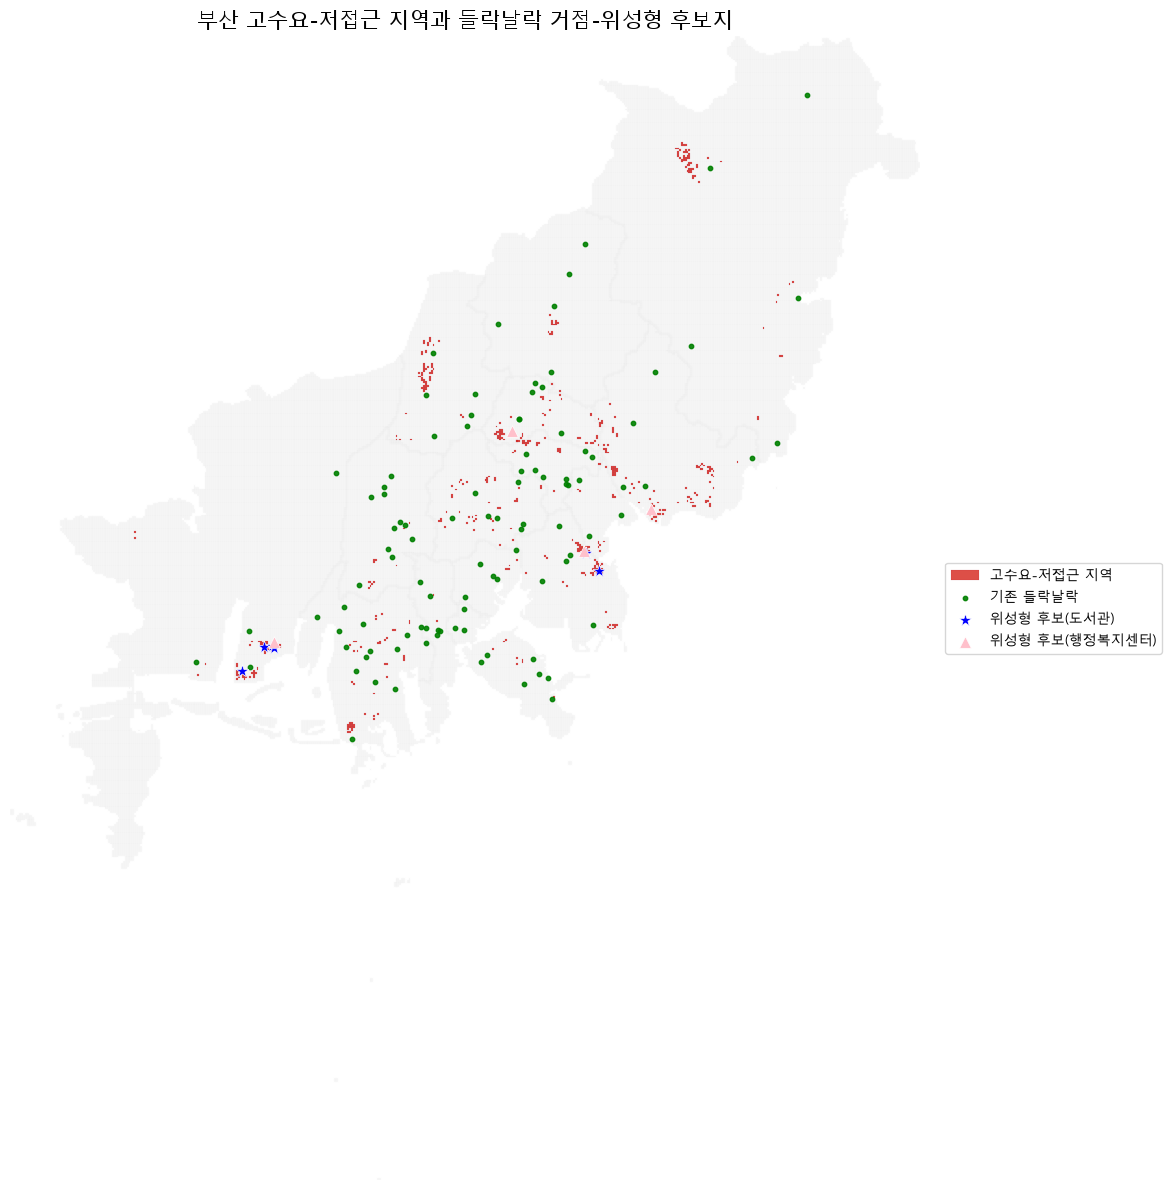

In [54]:
fig, ax = plt.subplots(figsize=(12, 12))

# --------------------------------------------------
# 1. 전체 격자 배경
# --------------------------------------------------
gdf.plot(
    ax=ax,
    color="#F2F2F2",
    edgecolor="#E6E6E6",
    linewidth=0.03,
    alpha=0.5
)

# --------------------------------------------------
# 2. 고수요-저접근성 부족지역 강조
# --------------------------------------------------
gdf[gdf["gap_type"] == "고수요-저접근성"].plot(
    ax=ax,
    color="#D73027",
    edgecolor="#A50026",
    linewidth=0.08,
    alpha=0.85,
    label="고수요-저접근 지역",
    zorder=5
)

# --------------------------------------------------
# 3. 기존 들락날락 표시
# --------------------------------------------------
dlnl_gdf.to_crs(gdf.crs).plot(
    ax=ax,
    color="green",
    markersize=10,
    marker="o",
    alpha=0.9,
    label="기존 들락날락",
    zorder=10
)

# --------------------------------------------------
# 4. 위성형 후보를 유형별로 분리
# --------------------------------------------------
satellite_selected = satellite_selected.to_crs(gdf.crs)

library_selected = satellite_selected[
    satellite_selected["candidate_type"] == "도서관"
].copy()

admin_selected = satellite_selected[
    satellite_selected["candidate_type"] == "행정복지센터"
].copy()

# --------------------------------------------------
# 5. 도서관 후보 표시
# --------------------------------------------------
if not library_selected.empty:
    library_selected.plot(
        ax=ax,
        color="blue",
        markersize=90,
        marker="*",
        edgecolor="white",
        linewidth=0.5,
        alpha=1.0,
        label="위성형 후보(도서관)",
        zorder=11
    )

# --------------------------------------------------
# 6. 행정복지센터 후보 표시
# --------------------------------------------------
if not admin_selected.empty:
    admin_selected.plot(
        ax=ax,
        color="pink",
        markersize=70,
        marker="^",
        edgecolor="white",
        linewidth=0.5,
        alpha=1.0,
        label="위성형 후보(행정복지센터)",
        zorder=12
    )

# --------------------------------------------------
# 8. 지도 범위 설정
# --------------------------------------------------
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# --------------------------------------------------
# 9. 제목 / 범례 / 축 제거
# --------------------------------------------------
ax.set_title(
    "부산 고수요-저접근 지역과 들락날락 거점-위성형 후보지",
    fontsize=15
)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_axis_off()
plt.tight_layout()

plt.savefig(
    "부산_고수요_저접근_들락날락_거점_위성형_지도.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
print("지도에 표시된 위성형 후보지 수:", len(satellite_selected))

지도에 표시된 위성형 후보지 수: 10
